# 06 — TCN v1: Regime Gate · Symmetric Fees · Direction Balance

Extends TCN v0 (Sharpe=0.457) with three targeted fixes for the long/short imbalance
(v0: 53 longs vs 542 shorts) and punishing taker-fee drag on the long side.

| Dimension | v0 | v1 | Why |
|---|---|---|---|
| **Long entry fee** | All-taker 0.05% | Limit entry: MAKER 0% if filled, SPOT_TAKER fallback | Removes asymmetric cost disadvantage for longs |
| **Long TP fee** | SPOT_TAKER 0.05% | MAKER 0% | Symmetric with short TP |
| **Regime filter** | None | SMA-200 gate (grid param) | Block longs in bear trend, shorts in bull trend |
| **Min long ratio** | None | ≥10% of trades | Rejects grid combos that are short-only in disguise |
| **Short threshold floor** | 0.32 | 0.36 | Raise bar for short entry, encourage balance |


In [1]:
import calendar
import itertools
import json
import math
import pickle
import random
import time
import warnings
from collections import Counter
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import QuantileTransformer
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
if torch.cuda.is_available():                                   DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
                                                                DEVICE = torch.device('mps')
else:                                                           DEVICE = torch.device('cpu')

# ── Matplotlib style ─────────────────────────────────────────────────────────
try:    plt.style.use('seaborn-v0_8-whitegrid')
except: plt.style.use('seaborn-whitegrid')
mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'
RED='#EF5350';   GREEN='#26A69A'; PURPLE='#7B1FA2'

# ── Data framing ─────────────────────────────────────────────────────────────
SYMBOL   = 'BTCUSDT'
INTERVAL = '1h'
TRAIN_END = '2024-01-01'   # train up to LGBM OOS start
VAL_END   = '2024-11-10'   # val = pre-ATH period (same ATH pivot as LGBM display)
# Test: VAL_END → latest = ATH window, directly comparable to LGBM v12

# ── Fractional differentiation ───────────────────────────────────────────────
FRAC_D    = 0.4
FFD_THRES = 1e-4

# ── Triple Barrier Method ─────────────────────────────────────────────────────
TBM_VOL_WINDOW = 24   # rolling window for σ estimate (hours)
TBM_MULT       = 2.0  # ±2σ barriers
TBM_VERT_H     = 24   # vertical time barrier (hours)

# ── Auxiliary target ─────────────────────────────────────────────────────────
AUX_FWD_H = 6   # forward hours for realised-vol regression target

# ── Sequences ────────────────────────────────────────────────────────────────
SEQ_LEN = 48   # 2-day lookback

# ── TCN architecture ─────────────────────────────────────────────────────────
TCN_CHANNELS = [64, 64, 64, 64]   # dilations = 1, 2, 4, 8
TCN_KERNEL   = 3
TCN_DROPOUT  = 0.20

# ── Training ─────────────────────────────────────────────────────────────────
EPOCHS        = 100
WARMUP_EPOCHS = 5
BATCH_SIZE    = 256
LR            = 3e-4
WEIGHT_DECAY  = 1e-4
PATIENCE      = 20
LAMBDA_VOL    = 0.50

# ── Fee model (v1: SYMMETRIC limit-entry for both sides) ─────────────────────
# LONG:  limit entry (MAKER 0% if lo touches lim, SPOT_TAKER 0.05% fallback)
#        MAKER 0% TP  |  SPOT_TAKER SL & timeout
# SHORT: limit entry (MAKER 0% if hi touches lim, FUTURES_TAKER 0.05% fallback)
#        MAKER 0% TP  |  FUTURES_TAKER SL & timeout
MAKER_FEE         = 0.0000   # 0%    — limit fills & TP exits (both sides)
SPOT_TAKER_FEE    = 0.0005   # 0.05% — long SL, long timeout, long limit-miss
FUTURES_TAKER_FEE = 0.0005   # 0.05% — short SL, short timeout, short limit-miss
BUFFER            = 0.0005   # 5 bp fill buffer for limit orders
SHORT_FUNDING_H   = 0.0000077  # +0.00077%/h received on short positions
MIN_SL            = 0.010    # minimum stop-loss as fraction of price

# ── Balance constraint ────────────────────────────────────────────────────────
MIN_LONG_RATIO = 0.10  # grid search rejects combos with longs < 10% of total trades

# ── Features (from V1 + V4 + structural + fracdiff) ──────────────────────────
LGBM_CORE = [
    'stoch_k_14', 'ret_2h', 'rsi_divergence', 'close_vs_sma_7',
    'bear_streak', 'close_vs_s1', 'macd_hist_5_13', 'ad_z_48h', 'ret_3h',
]
V1_EXTRA = [
    'ret_1h', 'rsi_14', 'vol_ratio_24h', 'bb_position_20',
    'hour_sin', 'hour_cos', 'atr_14_pct', 'hurst_168h',
    'trend_score', 'close_vs_sma_50', 'ma_bull_score',
]
V4_FEATURES = [
    'close_vs_true_vwap', 'hurst_24h', 'hurst_72h',
    'tfi_pct', 'tfi_z_24h', 'bb_width_pct', 'sideways_flag',
]
STRUCT_FEATURES = [
    'liq_vwap_dev_24h', 'volat_atr_20_pct', 'mtf_alignment', 'mtf_h4_rsi',
]
BASE_FEATURES = LGBM_CORE + V1_EXTRA + V4_FEATURES + STRUCT_FEATURES

# ── Trading execution grid (v1: regime_filter added, short_threshold floor raised) ──
TRADING_GRID = {
    'long_threshold':  [0.36, 0.40, 0.44, 0.48],
    'short_threshold': [0.36, 0.40, 0.44, 0.48],
    'entry_atr_mult':  [0.0, 0.3, 0.6],
    'sl_atr_mult':     [1.5, 2.0, 2.5],
    'tp_atr_mult':     [2.0, 2.5, 3.0],
    'min_hold':        [6, 12],
    'max_hold':        [24, 48],
    'cooldown':        [2, 3],
    'regime_filter':   [True, False],
}
_all_combos = list(itertools.product(*TRADING_GRID.values()))
_grid_keys  = list(TRADING_GRID.keys())

print(f'Device         : {DEVICE}')
print(f'Full grid      : {len(_all_combos):,} combos')
print(f'Base features  : {len(BASE_FEATURES)}  (+ fracdiff = {len(BASE_FEATURES)+1} total)')
print(f'Receptive field: {1 + 2*(TCN_KERNEL-1)*sum(2**i for i in range(len(TCN_CHANNELS)))} timesteps  '
      f'(SEQ_LEN={SEQ_LEN})')
print('Imports OK')


Device         : mps
Full grid      : 6,912 combos
Base features  : 31  (+ fracdiff = 32 total)
Receptive field: 61 timesteps  (SEQ_LEN=48)
Imports OK


In [2]:
def _find_repo_root() -> Path:
    p = Path.cwd()
    while p != p.parent:
        if (p / 'pyproject.toml').exists(): return p
        p = p.parent
    raise RuntimeError('repo root not found')

REPO_DIR  = _find_repo_root()
FEAT_DIR  = REPO_DIR / 'data' / 'features'
RAW_DIR   = REPO_DIR / 'data' / 'raw'
EXT_DIR   = REPO_DIR / 'data' / 'external'
ARTS_DIR  = REPO_DIR / 'artifacts' / '06_tcn_omni_0fee_v0'
MODELS_DIR= REPO_DIR / 'local_models'
ARTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)
print(f'Repo    : {REPO_DIR}')
print(f'Artifacts → {ARTS_DIR}')

Repo    : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system
Artifacts → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/06_tcn_omni_0fee_v0


## 1. Load & merge features

Merges V1 (OHLCV-derived), V4 (microstructure + regime), and structural features into a single DataFrame aligned on the V1 hourly index.

In [3]:
print('Loading V1 features  (199 cols)...')
v1 = pd.read_parquet(FEAT_DIR / f'{SYMBOL}_{INTERVAL}_features.parquet')
v1.index = v1.index.tz_localize(None) if v1.index.tz else v1.index

print('Loading V4 features  (25 cols: microstructure + regime)...')
v4 = pd.read_parquet(FEAT_DIR / f'{SYMBOL}_{INTERVAL}_v4_features.parquet')
v4.index = v4.index.tz_localize(None) if v4.index.tz else v4.index

print('Loading structural features  (39 cols)...')
struct = pd.read_parquet(FEAT_DIR / f'{SYMBOL}_{INTERVAL}_structural.parquet')
struct.index = struct.index.tz_convert(None) if struct.index.tz else struct.index

print('Loading raw OHLC  (for high/low in backtester)...')
raw = pd.read_parquet(RAW_DIR / f'{SYMBOL}_{INTERVAL}.parquet')
raw.index = raw.index.tz_convert(None) if raw.index.tz else raw.index

# Start from V1 as the master index
df = v1.copy()
df['high'] = raw['high'].reindex(df.index)
df['low']  = raw['low'].reindex(df.index)

# Attach V4 columns needed
for col in V4_FEATURES:
    if col in v4.columns:
        df[col] = v4[col].reindex(df.index)
    else:
        print(f'  WARNING: {col} not in V4')

# Attach structural columns needed
for col in STRUCT_FEATURES:
    if col in struct.columns:
        df[col] = struct[col].reindex(df.index)
    else:
        print(f'  WARNING: {col} not in structural')

# Verify all base features exist
missing = [f for f in BASE_FEATURES if f not in df.columns]
if missing:
    print(f'MISSING features: {missing}')
else:
    print(f'All {len(BASE_FEATURES)} base features present ✓')

print(f'\nDataFrame: {df.shape[0]:,} rows  {df.index[0].date()} → {df.index[-1].date()}')
print(f'  - atr_14_pct range: [{df["atr_14_pct"].min():.4f}, {df["atr_14_pct"].max():.4f}]')

Loading V1 features  (199 cols)...
Loading V4 features  (25 cols: microstructure + regime)...
Loading structural features  (39 cols)...
Loading raw OHLC  (for high/low in backtester)...
All 31 base features present ✓

DataFrame: 74,366 rows  2017-11-15 → 2026-05-16
  - atr_14_pct range: [0.0007, 0.1107]


## 2. Fractional Differentiation (FFD)

Raw log-price is non-stationary (unit root); plain returns discard long-memory.
**FFD** finds the minimum differentiation order `d` that passes an ADF unit-root test
while preserving maximum autocorrelation structure.

Weight of lag $k$: $w_k = -w_{k-1}/k \times (d-k+1)$, truncated when $|w_k| <$ threshold.
The resulting series `fracdiff_close` is added as the 33rd input feature.

In [4]:
def _ffd_weights(d: float, thres: float = 1e-4) -> np.ndarray:
    w = [1.0]; k = 1
    while True:
        w_k = -w[-1] / k * (d - k + 1)
        if abs(w_k) < thres: break
        w.append(w_k); k += 1
    return np.array(w[::-1], dtype=np.float64)  # oldest→newest


def frac_diff_ffd(series: pd.Series, d: float, thres: float = 1e-4) -> pd.Series:
    weights = _ffd_weights(d, thres)
    width   = len(weights)
    vals    = series.values.astype(np.float64)
    out     = np.full(len(vals), np.nan)
    for i in range(width - 1, len(vals)):
        out[i] = np.dot(weights, vals[i - width + 1: i + 1])
    return pd.Series(out, index=series.index, name='fracdiff_close')


log_close  = np.log(df['close'])
d_opt      = FRAC_D  # default

try:
    from statsmodels.tsa.stattools import adfuller
    train_log = log_close[log_close.index < TRAIN_END]
    print('ADF stationarity sweep on training close:')
    for d_test in np.arange(0.1, 1.01, 0.1):
        fd   = frac_diff_ffd(train_log, round(float(d_test), 1), FFD_THRES).dropna()
        pval = adfuller(fd.values, maxlag=1, regression='c', autolag=None)[1]
        marker = '  ← selected (first d with p < 0.01)' if pval < 0.01 and d_opt == FRAC_D else ''
        print(f'  d={d_test:.1f}  p={pval:.4f}{marker}')
        if pval < 0.01 and d_opt == FRAC_D:
            d_opt = round(float(d_test), 1)
except ImportError:
    print(f'statsmodels not available; using default d={d_opt}')

df['fracdiff_close'] = frac_diff_ffd(log_close, d_opt, FFD_THRES)
ffd_nan_rows = df['fracdiff_close'].isna().sum()
print(f'\nUsing d={d_opt}  |  FFD window = {ffd_nan_rows} leading NaN rows')

ALL_FEATURES = BASE_FEATURES + ['fracdiff_close']
print(f'Total input features: {len(ALL_FEATURES)}')

ADF stationarity sweep on training close:
  d=0.1  p=0.3068
  d=0.2  p=0.0016  ← selected (first d with p < 0.01)
  d=0.3  p=0.0000
  d=0.4  p=0.0000
  d=0.5  p=0.0000
  d=0.6  p=0.0000
  d=0.7  p=0.0000
  d=0.8  p=0.0000
  d=0.9  p=0.0000
  d=1.0  p=0.0000

Using d=0.2  |  FFD window = 496 leading NaN rows
Total input features: 32


## 3. Triple Barrier Method labels

For each bar $t$:
- $\sigma_t$ = 24h rolling std of log-returns
- **Upper barrier**: `close[t] × (1 + 2σ)` → label **1** (Up)
- **Lower barrier**: `close[t] × (1 − 2σ)` → label **0** (Down)
- **Vertical barrier**: `t + 24h` → label **2** (Flat / no edge)

Using ±2σ (vs ±1σ in TCN v11) increases the signal-to-noise ratio:
wider barriers require a stronger move → fewer flat bars, cleaner directional labels.

In [5]:
log_rets    = log_close.diff()
rolling_vol = log_rets.rolling(TBM_VOL_WINDOW).std()

close_vals = df['close'].values
vol_vals   = rolling_vol.values
n          = len(close_vals)
tbm_labels = np.full(n, np.nan)

t0 = time.time()
for i in range(n - TBM_VERT_H):
    if np.isnan(vol_vals[i]) or vol_vals[i] <= 0: continue
    upper = close_vals[i] * (1.0 + TBM_MULT * vol_vals[i])
    lower = close_vals[i] * (1.0 - TBM_MULT * vol_vals[i])
    label = 2  # default: time barrier
    for j in range(1, TBM_VERT_H + 1):
        px = close_vals[i + j]
        if   px >= upper: label = 1; break
        elif px <= lower: label = 0; break
    tbm_labels[i] = label

df['tbm_label'] = tbm_labels
valid   = df['tbm_label'].dropna()
counts  = valid.value_counts().sort_index()
names   = {0: 'Down (0)', 1: 'Up (1)', 2: 'Flat (2)'}
print(f'TBM labelling done in {time.time()-t0:.1f}s')
print(f'Barriers: ±{TBM_MULT}σ  (σ = {TBM_VOL_WINDOW}h rolling)  vertical = {TBM_VERT_H}h')
print('\nFull dataset distribution:')
for lbl, cnt in counts.items():
    print(f'  {names[lbl]}: {cnt:>7,}  ({cnt/len(valid)*100:.1f}%)')
print(f'  Total valid: {len(valid):,} / {n:,}')

TBM labelling done in 0.1s
Barriers: ±2.0σ  (σ = 24h rolling)  vertical = 24h

Full dataset distribution:
  Down (0):  32,379  (43.6%)
  Up (1):  33,704  (45.4%)
  Flat (2):   8,235  (11.1%)
  Total valid: 74,318 / 74,366


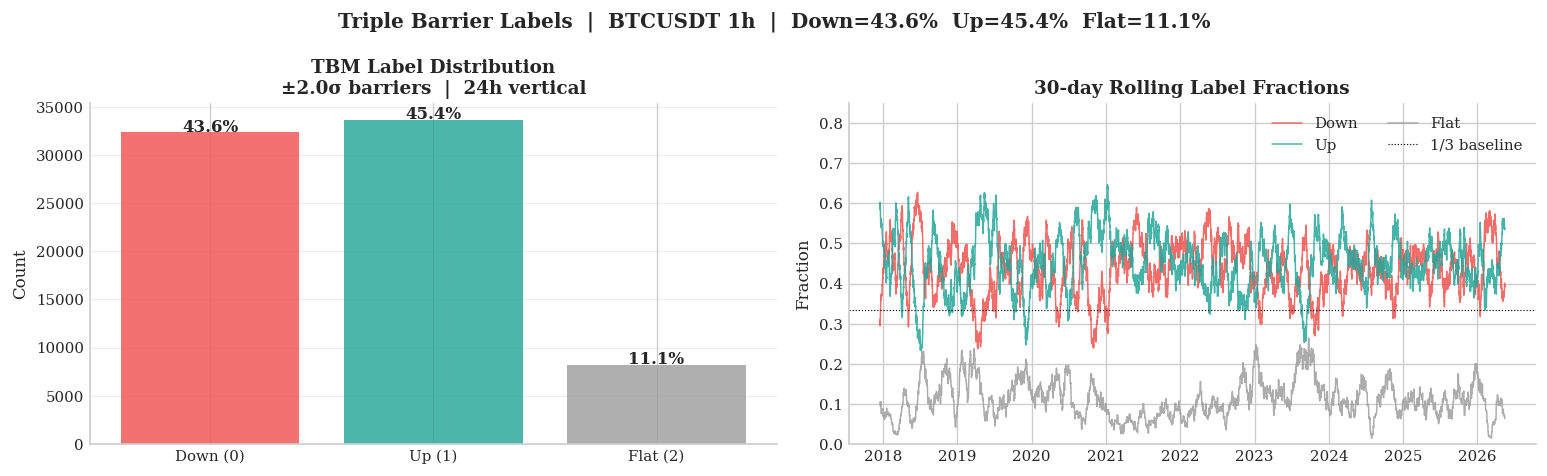

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
ax = axes[0]
colors = [RED, GREEN, GREY]
bar_vals = [counts.get(k, 0) for k in [0, 1, 2]]
bars = ax.bar([names[k] for k in [0, 1, 2]], bar_vals, color=colors, alpha=0.82)
for bar, v in zip(bars, bar_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 120,
            f'{v/len(valid)*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title(f'TBM Label Distribution\n±{TBM_MULT}σ barriers  |  {TBM_VERT_H}h vertical',
             fontweight='bold')
ax.set_ylabel('Count'); ax.grid(axis='y', alpha=0.3)

# Rolling fractions
ax = axes[1]
roll_w = 720  # 30-day rolling
lbl_series = df['tbm_label'].dropna()
for lbl, col, name in [(0, RED, 'Down'), (1, GREEN, 'Up'), (2, GREY, 'Flat')]:
    frac = (lbl_series == lbl).rolling(roll_w).mean()
    ax.plot(frac.index, frac, color=col, lw=0.9, alpha=0.85, label=name)
ax.axhline(1/3, color='black', ls=':', lw=0.7, label='1/3 baseline')
ax.set_title('30-day Rolling Label Fractions', fontweight='bold')
ax.set_ylabel('Fraction'); ax.legend(ncol=2); ax.set_ylim(0, 0.85)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle(
    f'Triple Barrier Labels  |  BTCUSDT 1h  |  '
    f'Down={counts.get(0,0)/len(valid)*100:.1f}%  '
    f'Up={counts.get(1,0)/len(valid)*100:.1f}%  '
    f'Flat={counts.get(2,0)/len(valid)*100:.1f}%',
    fontweight='bold'
)
fig.tight_layout()
fig.savefig(ARTS_DIR / '01_tbm_label_dist.png')
plt.show()

## 4. Auxiliary target: forward realised volatility

Volatility is strongly autocorrelated (GARCH clustering). Predicting forward realised vol
is an **easy** task the TCN can solve early in training, forcing it to build useful
market-regime representations that the direction head can then exploit.

Sample weights = concurrent 24h vol / median vol, clipped to [0.3, 3.0].
High-volatility bars carry stronger gradient signal.

In [7]:
# Forward AUX_FWD_H realised vol
fwd_vol = pd.concat(
    [log_rets.shift(-h) for h in range(1, AUX_FWD_H + 1)], axis=1
).std(axis=1)
df['fwd_vol'] = fwd_vol

# Sample weights
curr_vol = rolling_vol.fillna(rolling_vol.median())
df['sample_weight'] = (curr_vol / curr_vol.median()).clip(0.3, 3.0).fillna(1.0)

print(f'Forward {AUX_FWD_H}h vol — mean: {fwd_vol.mean()*100:.4f}%  '
      f'std: {fwd_vol.std()*100:.4f}%')
print(f'Sample weights  — mean: {df["sample_weight"].mean():.3f}  '
      f'range: [{df["sample_weight"].min():.3f}, {df["sample_weight"].max():.3f}]')

Forward 6h vol — mean: 0.5588%  std: 0.5196%
Sample weights  — mean: 1.170  range: [0.300, 3.000]


## 5. Feature assembly + train / val / test split

**Splits:**
- **Train**: start → 2024-01-01 (aligns with LGBM OOS start)
- **Val**: 2024-01-01 → 2024-11-10 (early stopping + grid search)
- **Test**: 2024-11-10 → latest (= LGBM ATH window for direct comparison)

In [8]:
# atr_14_pct is already inside ALL_FEATURES (V1_EXTRA) — deduplicate to avoid
# pandas returning duplicate columns when indexing.
# sma_200 is needed by the regime filter in the backtester (not a model feature).
_extra_cols = ['tbm_label', 'fwd_vol', 'sample_weight', 'high', 'low', 'close',
               'atr_14_pct', 'sma_200']
required_cols = list(dict.fromkeys(ALL_FEATURES + _extra_cols))  # preserves order, drops dupes

_overlap = set(ALL_FEATURES) & set(_extra_cols)
if _overlap:
    print(f'NOTE: {_overlap} appear in both ALL_FEATURES and extra cols — de-duplicated ✓')

clean_df = df[required_cols].dropna()
print(f'After NaN drop: {len(clean_df):,} rows  (dropped {len(df)-len(clean_df):,})')
print(f'Columns in clean_df: {len(clean_df.columns)}  (ALL_FEATURES={len(ALL_FEATURES)} + {len(required_cols)-len(ALL_FEATURES)} backtest cols)')

TRAIN_MASK = clean_df.index < TRAIN_END
VAL_MASK   = (clean_df.index >= TRAIN_END) & (clean_df.index < VAL_END)
TEST_MASK  = clean_df.index >= VAL_END

train_df = clean_df[TRAIN_MASK].copy()
val_df   = clean_df[VAL_MASK].copy()
test_df  = clean_df[TEST_MASK].copy()

print(f'\nSplit summary:')
print(f'  Train: {len(train_df):>7,}  {train_df.index[0].date()} → {train_df.index[-1].date()}')
print(f'  Val:   {len(val_df):>7,}  {val_df.index[0].date()} → {val_df.index[-1].date()}')
print(f'  Test:  {len(test_df):>7,}  {test_df.index[0].date()} → {test_df.index[-1].date()}')
for name, d in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    vc = d['tbm_label'].value_counts(normalize=True).sort_index()
    print(f'  {name} labels: down={vc.get(0,0)*100:.1f}%  up={vc.get(1,0)*100:.1f}%  flat={vc.get(2,0)*100:.1f}%')


NOTE: {'atr_14_pct'} appear in both ALL_FEATURES and extra cols — de-duplicated ✓
After NaN drop: 73,846 rows  (dropped 520)
Columns in clean_df: 39  (ALL_FEATURES=32 + 7 backtest cols)

Split summary:
  Train:  53,085  2017-12-06 → 2023-12-31
  Val:     7,536  2024-01-01 → 2024-11-09
  Test:   13,225  2024-11-10 → 2026-05-15
  Train labels: down=43.6%  up=45.0%  flat=11.4%
  Val labels: down=42.4%  up=46.4%  flat=11.3%
  Test labels: down=44.6%  up=45.6%  flat=9.8%


## 6. Normalisation (QuantileTransformer) + sequence building

`QuantileTransformer(output_distribution='normal')` maps each feature to a standard normal,
collapsing outliers that would otherwise dominate gradients in volatile regimes.
**Fitted on training set only** — val and test are transformed (not fit) to prevent leakage.

In [9]:
qt = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=SEED)
X_train_raw = qt.fit_transform(train_df[ALL_FEATURES].values).astype(np.float32)
X_val_raw   = qt.transform(val_df[ALL_FEATURES].values).astype(np.float32)
X_test_raw  = qt.transform(test_df[ALL_FEATURES].values).astype(np.float32)

# Save transformer + feature list
(MODELS_DIR / 'tcn_v0_qt.pkl').write_bytes(pickle.dumps(qt))
pd.Series(ALL_FEATURES).to_csv(MODELS_DIR / 'tcn_v0_features.csv', index=False, header=False)


def make_sequences(X_norm, y_dir, y_vol, weights, seq_len=SEQ_LEN):
    """Sliding window sequences: returns (X, y_dir, y_vol, weights)."""
    Xs, yd, yv, ws = [], [], [], []
    for i in range(seq_len, len(X_norm)):
        Xs.append(X_norm[i - seq_len: i])
        yd.append(y_dir[i]); yv.append(y_vol[i]); ws.append(weights[i])
    return (np.array(Xs, np.float32), np.array(yd, np.int64),
            np.array(yv, np.float32), np.array(ws, np.float32))


X_tr, y_tr_d, y_tr_v, w_tr = make_sequences(
    X_train_raw, train_df['tbm_label'].values.astype(int),
    train_df['fwd_vol'].values, train_df['sample_weight'].values)
X_vl, y_vl_d, y_vl_v, w_vl = make_sequences(
    X_val_raw, val_df['tbm_label'].values.astype(int),
    val_df['fwd_vol'].values, val_df['sample_weight'].values)
X_te, y_te_d, y_te_v, w_te = make_sequences(
    X_test_raw, test_df['tbm_label'].values.astype(int),
    test_df['fwd_vol'].values, test_df['sample_weight'].values)

print(f'X_train: {X_tr.shape}  X_val: {X_vl.shape}  X_test: {X_te.shape}')
print(f'  → each sample: {SEQ_LEN}h × {len(ALL_FEATURES)} features')

# Class weights for direction head (inverse frequency)
cnt = Counter(y_tr_d.tolist())
total_tr = sum(cnt.values())
class_weights = torch.tensor(
    [total_tr / (3 * cnt.get(c, 1)) for c in range(3)], dtype=torch.float32
).to(DEVICE)
print(f'Class weights: down={class_weights[0]:.3f}  up={class_weights[1]:.3f}  flat={class_weights[2]:.3f}')

X_train: (53037, 48, 32)  X_val: (7488, 48, 32)  X_test: (13177, 48, 32)
  → each sample: 48h × 32 features
Class weights: down=0.764  up=0.741  flat=2.933


## 7. TCN architecture

```
Input (B, T=48, F=33)  →  transpose  →  (B, F=33, T=48)
  Block 1: CausalConv(dil=1)×2 + residual  →  (B, 64, 48)
  Block 2: CausalConv(dil=2)×2 + residual  →  (B, 64, 48)
  Block 3: CausalConv(dil=4)×2 + residual  →  (B, 64, 48)
  Block 4: CausalConv(dil=8)×2 + residual  →  (B, 64, 48)
  Last timestep  →  (B, 64)
  ├── Head A: LayerNorm → Linear(64→32) → GELU → Dropout → Linear(32→3)   [direction]
  └── Head B: LayerNorm → Linear(64→16) → GELU → Linear(16→1) → Softplus  [vol regression]
```

Receptive field with kernel=3, dilations [1,2,4,8]: `1 + 2×2×15 = 61 > SEQ_LEN=48` ✓

**WeightNorm** on all Conv1d layers stabilises training; **residual connections** prevent
gradient vanishing; **GELU** heads are smoother than ReLU for classification.

In [10]:
# ── derive input_dim from the actual data tensor (immune to out-of-order re-runs) ──
N_FEATURES = X_tr.shape[2]  # (batch, time, features)
assert N_FEATURES == len(ALL_FEATURES), (
    f'Feature mismatch: sequences have {N_FEATURES} channels but '
    f'ALL_FEATURES has {len(ALL_FEATURES)} entries. '
    f'Re-run cells in order from Section 2 (FFD) through Section 6 (sequences).'
)

class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation):
        super().__init__()
        self.pad  = (kernel - 1) * dilation
        self.conv = nn.utils.weight_norm(
            nn.Conv1d(in_ch, out_ch, kernel, dilation=dilation, padding=self.pad)
        )
    def forward(self, x):
        out = self.conv(x)
        return out[:, :, :-self.pad] if self.pad > 0 else out


class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation, dropout):
        super().__init__()
        self.net = nn.Sequential(
            CausalConv1d(in_ch, out_ch, kernel, dilation), nn.ReLU(inplace=True), nn.Dropout(dropout),
            CausalConv1d(out_ch, out_ch, kernel, dilation), nn.ReLU(inplace=True), nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
    def forward(self, x):
        res = self.downsample(x) if self.downsample is not None else x
        return F.relu(self.net(x) + res)


class TCNMultiTask(nn.Module):
    """Causal TCN with dual heads: 3-class direction + vol regression."""
    def __init__(self, input_dim, channels, kernel, dropout):
        super().__init__()
        blocks = []; in_ch = input_dim
        for i, out_ch in enumerate(channels):
            blocks.append(TCNBlock(in_ch, out_ch, kernel, dilation=2**i, dropout=dropout))
            in_ch = out_ch
        self.tcn = nn.Sequential(*blocks)
        d = channels[-1]
        self.head_dir = nn.Sequential(
            nn.LayerNorm(d), nn.Linear(d, 32), nn.GELU(),
            nn.Dropout(dropout * 0.5), nn.Linear(32, 3),
        )
        self.head_vol = nn.Sequential(
            nn.LayerNorm(d), nn.Linear(d, 16), nn.GELU(),
            nn.Linear(16, 1), nn.Softplus(),
        )
    def forward(self, x):
        out  = self.tcn(x.transpose(1, 2))  # (B,F,T)
        last = out[:, :, -1]                 # last timestep (B, C)
        return self.head_dir(last), self.head_vol(last).squeeze(-1)


model = TCNMultiTask(
    input_dim=N_FEATURES,          # ← from tensor, not from list variable
    channels=TCN_CHANNELS, kernel=TCN_KERNEL, dropout=TCN_DROPOUT,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
rf = 1 + 2 * (TCN_KERNEL - 1) * sum(2**i for i in range(len(TCN_CHANNELS)))
print(f'Input dim (from tensor)  : {N_FEATURES}  (ALL_FEATURES list: {len(ALL_FEATURES)} ✓)')
print(f'Trainable parameters     : {n_params:,}')
print(f'Receptive field          : {rf} timesteps  (SEQ_LEN={SEQ_LEN}  {"OK ✓" if rf>=SEQ_LEN else "WARNING: RF < SEQ_LEN"})')
print(f'Input shape per batch    : (B, {SEQ_LEN}, {N_FEATURES})')


Input dim (from tensor)  : 32  (ALL_FEATURES list: 32 ✓)
Trainable parameters     : 98,788
Receptive field          : 61 timesteps  (SEQ_LEN=48  OK ✓)
Input shape per batch    : (B, 48, 32)


## 8. Multi-task training

$\mathcal{L} = \mathcal{L}_{\text{CE}}^{\text{class-weighted}} \cdot w_{\text{vol}} + 
\lambda \cdot \mathcal{L}_{\text{Huber}} \cdot w_{\text{vol}}$

- **$\mathcal{L}_{\text{CE}}$**: inverse-frequency class-weighted cross-entropy (handles flat-class imbalance)
- **$\mathcal{L}_{\text{Huber}}$**: robust regression on forward {AUX_FWD_H}h realised vol
- **Sample weight $w_{\text{vol}}$**: current 24h vol / median vol — volatile regimes get larger gradients
- **LR**: linear warmup → cosine annealing
- **Early stopping**: patience=20 on val total loss

In [11]:
train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr_d),
                         torch.from_numpy(y_tr_v), torch.from_numpy(w_tr))
val_ds   = TensorDataset(torch.from_numpy(X_vl), torch.from_numpy(y_vl_d),
                         torch.from_numpy(y_vl_v), torch.from_numpy(w_vl))
train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS: return (epoch + 1) / WARMUP_EPOCHS
    p = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1.0 + math.cos(math.pi * p))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def step(batch, training):
    xb, yb_d, yb_v, wb = [t.to(DEVICE) for t in batch]
    logits, vol_pred    = model(xb)
    ce_per  = F.cross_entropy(logits, yb_d, weight=class_weights, reduction='none')
    hub_per = F.huber_loss(vol_pred, yb_v, reduction='none')
    loss    = (ce_per * wb).mean() + LAMBDA_VOL * (hub_per * wb).mean()
    if training:
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
    acc = (logits.argmax(1) == yb_d).float().mean().item()
    return loss.item(), (ce_per * wb).mean().item(), acc


hist = {k: [] for k in ['tl', 'vl', 'ta', 'va']}
best_vl, pat_cnt, best_state = float('inf'), 0, None
stopped_epoch = EPOCHS

print(f'Training TCN ({n_params:,} params) on {DEVICE} ...')
t_train = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    tl = ta = n_tr = 0
    for batch in train_loader:
        l, _, acc = step(batch, True)
        bs = len(batch[0]); tl += l*bs; ta += acc*bs; n_tr += bs

    model.eval()
    vl = va = n_vl = 0
    with torch.no_grad():
        for batch in val_loader:
            l, _, acc = step(batch, False)
            bs = len(batch[0]); vl += l*bs; va += acc*bs; n_vl += bs

    tl /= n_tr; vl /= n_vl; ta /= n_tr; va /= n_vl
    hist['tl'].append(tl); hist['vl'].append(vl)
    hist['ta'].append(ta); hist['va'].append(va)
    scheduler.step()

    if vl < best_vl:
        best_vl = vl
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        pat_cnt = 0
    else:
        pat_cnt += 1
        if pat_cnt >= PATIENCE:
            stopped_epoch = epoch
            print(f'Early stop at epoch {epoch}  (best val loss: {best_vl:.5f})')
            break

    if epoch % 5 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Ep {epoch:>3}/{EPOCHS}  '
              f'loss: tr={tl:.4f} vl={vl:.4f}  '
              f'acc: tr={ta:.4f} vl={va:.4f}  lr={lr_now:.2e}')

model.load_state_dict(best_state)
torch.save(model.state_dict(), MODELS_DIR / 'tcn_v0_model.pt')
print(f'\nTraining done in {(time.time()-t_train)/60:.1f} min  |  best_val_loss={best_vl:.5f}')
best_epoch = stopped_epoch - pat_cnt
print(f'Best epoch: {best_epoch}')

Training TCN (98,788 params) on mps ...
Ep   1/100  loss: tr=1.5263 vl=1.1625  acc: tr=0.1866 vl=0.1197  lr=1.20e-04
Ep   5/100  loss: tr=1.3018 vl=1.1250  acc: tr=0.3955 vl=0.3996  lr=3.00e-04
Ep  10/100  loss: tr=1.1955 vl=1.1389  acc: tr=0.4442 vl=0.3876  lr=2.98e-04
Ep  15/100  loss: tr=1.1135 vl=1.1858  acc: tr=0.4744 vl=0.4160  lr=2.92e-04
Ep  20/100  loss: tr=1.0370 vl=1.2136  acc: tr=0.5063 vl=0.3944  lr=2.82e-04
Early stop at epoch 25  (best val loss: 1.12498)

Training done in 0.9 min  |  best_val_loss=1.12498
Best epoch: 5


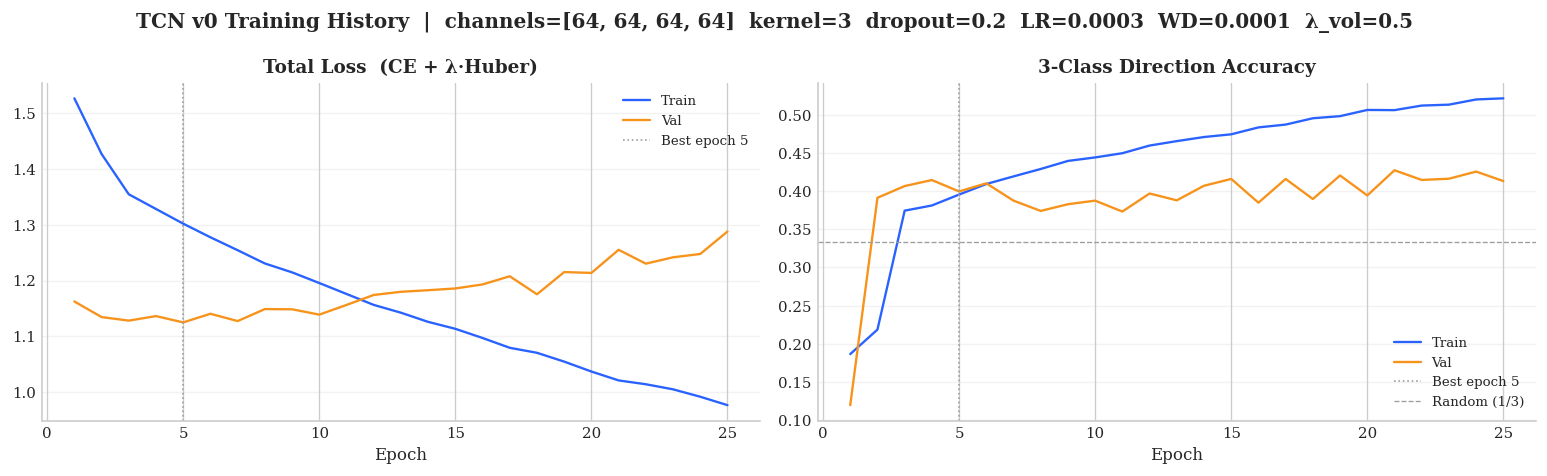

Best epoch: 5  train_acc=0.3955  val_acc=0.3996  overfit_gap=-0.0041


In [12]:
ran = range(1, len(hist['tl']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, tk, vk, title in [
    (axes[0], 'tl', 'vl', 'Total Loss  (CE + λ·Huber)'),
    (axes[1], 'ta', 'va', '3-Class Direction Accuracy'),
]:
    ax.plot(ran, hist[tk], color=BLUE,   lw=1.4, label='Train')
    ax.plot(ran, hist[vk], color=ACCENT, lw=1.4, label='Val')
    ax.axvline(best_epoch, color=GREY, ls=':', lw=1, label=f'Best epoch {best_epoch}')
    if 'Acc' in title: ax.axhline(1/3, color=GREY, ls='--', lw=0.8, label='Random (1/3)')
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch'); ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.25)

fig.suptitle(
    f'TCN v0 Training History  |  '
    f'channels={TCN_CHANNELS}  kernel={TCN_KERNEL}  dropout={TCN_DROPOUT}  '
    f'LR={LR}  WD={WEIGHT_DECAY}  λ_vol={LAMBDA_VOL}',
    fontweight='bold'
)
fig.tight_layout()
fig.savefig(ARTS_DIR / '02_training_history.png')
plt.show()
print(f'Best epoch: {best_epoch}  '
      f'train_acc={hist["ta"][best_epoch-1]:.4f}  '
      f'val_acc={hist["va"][best_epoch-1]:.4f}  '
      f'overfit_gap={hist["ta"][best_epoch-1]-hist["va"][best_epoch-1]:.4f}')

## 9. Test-set evaluation

Run inference on both the val set (for grid search) and the test set (held-out).

In [13]:
def run_inference(X, y, batch_size=512):
    model.eval()
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y),
                       torch.zeros(len(X)), torch.ones(len(X)))
    all_logits = []
    with torch.no_grad():
        for batch in DataLoader(ds, batch_size=batch_size):
            logits, _ = model(batch[0].to(DEVICE))
            all_logits.append(logits.cpu())
    logits_arr = torch.cat(all_logits).numpy()
    probs_arr  = torch.softmax(torch.from_numpy(logits_arr), dim=1).numpy()
    return probs_arr  # (N, 3): [down, up, flat]


print('Running inference on val set  (grid search)...')
probs_val  = run_inference(X_vl, y_vl_d)
print('Running inference on test set (held-out evaluation)...')
probs_test = run_inference(X_te, y_te_d)

def print_eval(probs, y, label):
    pred = probs.argmax(1)
    acc3  = (pred == y).mean()
    bmask = y != 2
    acc_b = (pred[bmask] == y[bmask]).mean()
    try:
        from sklearn.preprocessing import label_binarize
        yb = label_binarize(y, classes=[0, 1, 2])
        auc = roc_auc_score(yb, probs, multi_class='ovr', average='macro')
    except Exception:
        auc = float('nan')
    print(f'  {label}:')
    print(f'    3-class accuracy : {acc3:.4f}  (random baseline: {1/3:.4f})')
    print(f'    Binary accuracy  : {acc_b:.4f}  (up/down only)')
    print(f'    Macro AUC        : {auc:.4f}')
    print(f'    P(up)   — mean={probs[:,1].mean():.4f}  range=[{probs[:,1].min():.4f}, {probs[:,1].max():.4f}]')
    print(f'    P(down) — mean={probs[:,0].mean():.4f}  range=[{probs[:,0].min():.4f}, {probs[:,0].max():.4f}]')
    return {'acc3': acc3, 'acc_bin': acc_b, 'auc': auc}

val_metrics  = print_eval(probs_val,  y_vl_d, 'Val  (grid search)')
print()
test_metrics = print_eval(probs_test, y_te_d, 'Test (held-out)')

Running inference on val set  (grid search)...
Running inference on test set (held-out evaluation)...
  Val  (grid search):
    3-class accuracy : 0.3996  (random baseline: 0.3333)
    Binary accuracy  : 0.3929  (up/down only)
    Macro AUC        : 0.5940
    P(up)   — mean=0.3479  range=[0.0393, 0.5106]
    P(down) — mean=0.3732  range=[0.0316, 0.5803]

  Test (held-out):
    3-class accuracy : 0.4383  (random baseline: 0.3333)
    Binary accuracy  : 0.4683  (up/down only)
    Macro AUC        : 0.5523
    P(up)   — mean=0.3739  range=[0.1012, 0.4796]
    P(down) — mean=0.4249  range=[0.0804, 0.5833]


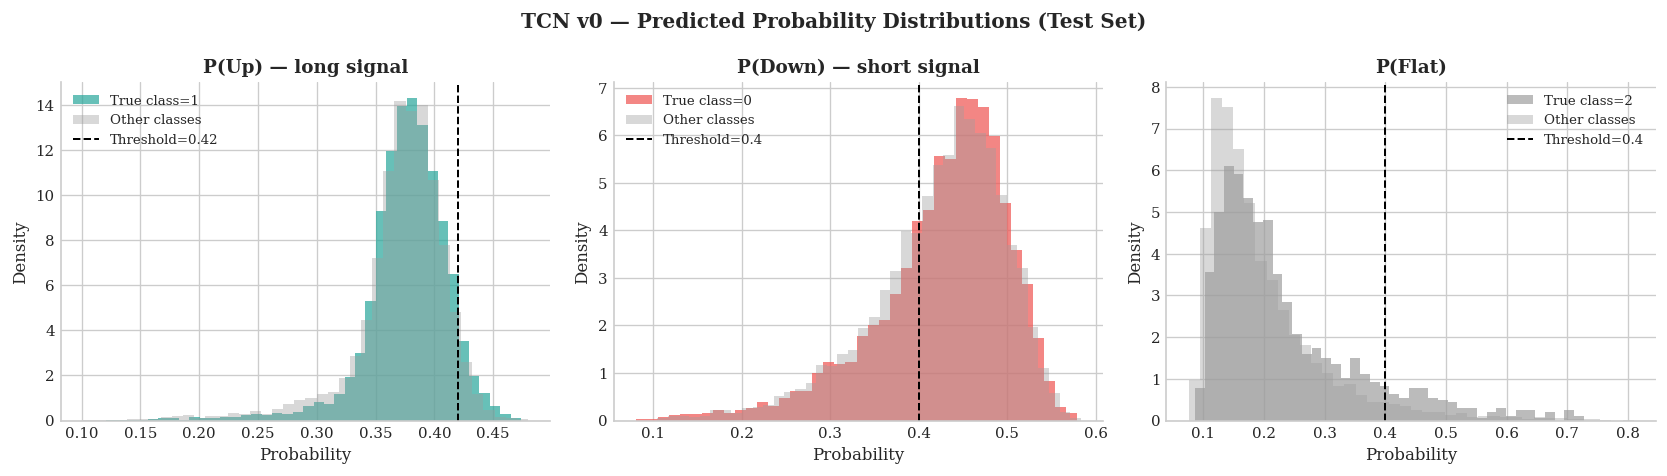

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
thr_long = 0.42; thr_short = 0.40  # illustrative (will be grid-searched)

for ax, cls_idx, title, thr, col in [
    (axes[0], 1, 'P(Up) — long signal',    thr_long,  GREEN),
    (axes[1], 0, 'P(Down) — short signal', thr_short, RED),
    (axes[2], 2, 'P(Flat)',                0.40,      GREY),
]:
    prob = probs_test[:, cls_idx]
    mask_true  = y_te_d == cls_idx
    mask_other = ~mask_true
    ax.hist(prob[mask_true],  bins=40, alpha=0.70, color=col,  density=True, label=f'True class={cls_idx}')
    ax.hist(prob[mask_other], bins=40, alpha=0.40, color=GREY, density=True, label='Other classes')
    ax.axvline(thr, color='black', ls='--', lw=1.2, label=f'Threshold={thr}')
    ax.set_xlabel('Probability'); ax.set_ylabel('Density')
    ax.set_title(title, fontweight='bold'); ax.legend(fontsize=8)

fig.suptitle('TCN v0 — Predicted Probability Distributions (Test Set)', fontweight='bold')
fig.tight_layout()
fig.savefig(ARTS_DIR / '03_confidence_dist.png')
plt.show()

## 10. Win rate by confidence bucket

Key diagnostic: if the model has learned a tradeable signal, bars where P(up) is high
should show a higher fraction of next-candle-up outcomes (and vice versa for P(down)).

We use the **actual next-close direction** (binary) rather than TBM labels,
so this is an independent check of the TCN's directional edge.

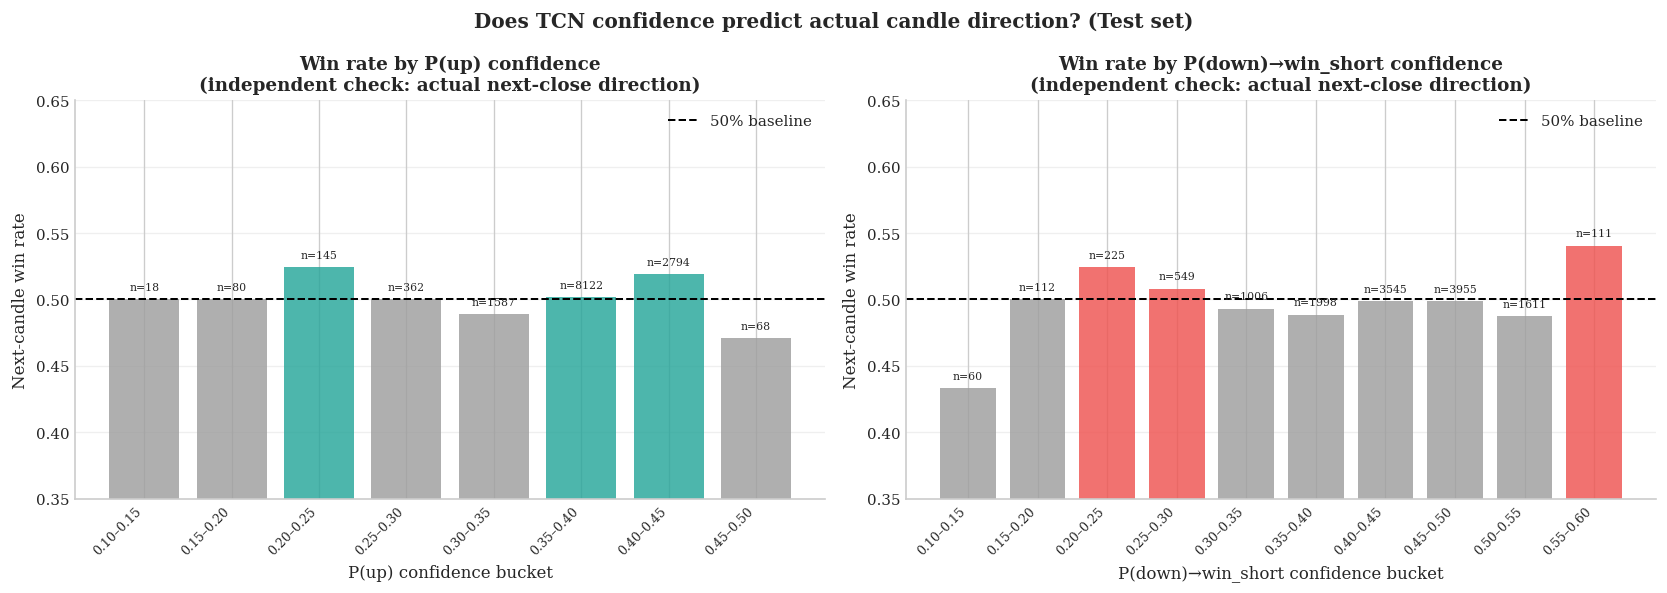

   bucket    n  win_rate              type
0.10–0.15   18    0.5000             P(up)
0.10–0.15   60    0.4333 P(down)→win_short
0.15–0.20   80    0.5000             P(up)
0.15–0.20  112    0.5000 P(down)→win_short
0.20–0.25  145    0.5241             P(up)
0.20–0.25  225    0.5244 P(down)→win_short
0.25–0.30  362    0.5000             P(up)
0.25–0.30  549    0.5082 P(down)→win_short
0.30–0.35 1587    0.4890             P(up)
0.30–0.35 1006    0.4930 P(down)→win_short
0.35–0.40 8122    0.5016             P(up)
0.35–0.40 1998    0.4885 P(down)→win_short
0.40–0.45 2794    0.5190             P(up)
0.40–0.45 3545    0.4987 P(down)→win_short
0.45–0.50   68    0.4706             P(up)
0.45–0.50 3955    0.4986 P(down)→win_short
0.50–0.55 1611    0.4873 P(down)→win_short
0.55–0.60  111    0.5405 P(down)→win_short


In [15]:
close_test = test_df['close'].values  # raw close prices for win-rate diagnostic

# Next-candle actual direction (independent of TBM)
# probs_test[k] → prediction for bar (SEQ_LEN + k) in test_df
# win_long[k]   = 1  if  close[SEQ_LEN+k+1] > close[SEQ_LEN+k]
n_seq = len(probs_test)
_c_curr = close_test[SEQ_LEN:     SEQ_LEN + n_seq]
_c_next = close_test[SEQ_LEN + 1: SEQ_LEN + n_seq + 1]
n_common = min(len(_c_curr), len(_c_next))  # last pred has no next candle → trim
actual_up = (_c_next[:n_common] > _c_curr[:n_common]).astype(float)

p_up_te   = probs_test[:n_common, 1]
p_down_te = probs_test[:n_common, 0]
au        = actual_up

rows = []
for lo in np.arange(0.0, 0.90, 0.05):
    hi = lo + 0.05
    for arr, name, win_fn in [
        (p_up_te,   'P(up)',              lambda m: au[m].mean()),
        (p_down_te, 'P(down)→win_short', lambda m: 1 - au[m].mean()),
    ]:
        mask = (arr >= lo) & (arr < hi)
        if mask.sum() < 15: continue
        rows.append({'bucket': f'{lo:.2f}–{hi:.2f}', 'n': int(mask.sum()),
                     'win_rate': win_fn(mask), 'type': name})
bkt = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, type_lbl, color in [
    (axes[0], 'P(up)',              GREEN),
    (axes[1], 'P(down)→win_short', RED),
]:
    sub = bkt[bkt['type'] == type_lbl].reset_index(drop=True)
    if sub.empty: ax.set_title(f'{type_lbl} — no data'); continue
    bcolors = [color if r > 0.5 else GREY for r in sub['win_rate']]
    ax.bar(range(len(sub)), sub['win_rate'], color=bcolors, alpha=0.82)
    ax.axhline(0.5, color='black', ls='--', lw=1.2, label='50% baseline')
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub['bucket'], rotation=45, ha='right', fontsize=7.5)
    for i, row in sub.iterrows():
        ax.text(i, row['win_rate'] + 0.007, f'n={row["n"]}', ha='center', fontsize=6.5)
    ax.set_xlabel(f'{type_lbl} confidence bucket')
    ax.set_ylabel('Next-candle win rate')
    ax.set_title(f'Win rate by {type_lbl} confidence\n'
                 f'(independent check: actual next-close direction)',
                 fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3); ax.set_ylim(0.35, 0.65)

fig.suptitle('Does TCN confidence predict actual candle direction? (Test set)', fontweight='bold')
fig.tight_layout()
fig.savefig(ARTS_DIR / '04_win_rate_by_bucket.png')
plt.show()
print(bkt.to_string(index=False))


## 11. Backtest engine + grid search

**Fee model v1 — symmetric limit-entry for both sides:**

| Side | Entry | SL exit | TP exit | Timeout |
|------|-------|---------|---------|---------|
| **Long** | `MAKER` 0% if `lo ≤ lim+buffer` else `SPOT_TAKER` 0.05% | `SPOT_TAKER` 0.05% | `MAKER` 0% | `SPOT_TAKER` 0.05% |
| **Short** | `MAKER` 0% if `hi ≥ lim−buffer` else `FUTURES_TAKER` 0.05% | `FUTURES_TAKER` 0.05% | `MAKER` 0% | `FUTURES_TAKER` 0.05% |

Both sides place a limit entry `entry_atr_mult × ATR` away from current price.
If not filled within one bar, the trade is **skipped** (no forced market fill).

**Regime filter (grid param):**
- `regime_filter=True`: LONG only when `close > SMA_200` (bull); SHORT only when `close < SMA_200` (bear)
- `regime_filter=False`: trade both directions regardless of trend

**Balance constraint:** grid combos with `n_long / n_trades < MIN_LONG_RATIO (10%)` are rejected.


In [16]:
def _run_backtest(
    p_up_arr, p_down_arr,
    close_arr, high_arr, low_arr, atr_arr, sma200_arr,
    long_threshold, short_threshold,
    entry_atr_mult, sl_atr_mult, tp_atr_mult,
    min_hold, max_hold, cooldown,
    regime_filter=False, with_fees=True,
):
    """
    v1: symmetric limit-entry for both long and short.
    Long:  limit entry (MAKER if lo<=lim+BUFFER, else SPOT_TAKER), MAKER TP, SPOT_TAKER SL/timeout.
    Short: limit entry (MAKER if hi>=lim-BUFFER, else FUTURES_TAKER), MAKER TP, FUTURES_TAKER SL/timeout.
    Regime filter: if enabled, long only in bull (close>SMA200), short only in bear (close<SMA200).
    """
    n   = len(close_arr)
    eq  = np.ones(n)
    cur = 1.0
    trades = []

    in_pos = False; direction = None
    entry_px = sl_px = tp_px = 0.0
    entry_fee = funding = 0.0; pos_eq = 1.0; hold_cnt = cd_cnt = 0
    pending = None  # ('long'|'short', lim, sl, tp)

    for i in range(n):
        lo = low_arr[i]; hi = high_arr[i]; px = close_arr[i]

        if in_pos:
            hold_cnt += 1
            if direction == 'short': funding += SHORT_FUNDING_H
            eq[i] = pos_eq * (px / entry_px if direction == 'long'
                              else 1.0 + (entry_px - px) / entry_px)

            exited = False; exit_px = 0.0; reason = ''; exit_fee = 0.0
            if hold_cnt >= min_hold:
                if direction == 'long':
                    if   lo <= sl_px:          exit_px=sl_px; exited=True; reason='sl';      exit_fee=SPOT_TAKER_FEE if with_fees else 0.
                    elif hi >= tp_px:          exit_px=tp_px; exited=True; reason='tp';      exit_fee=MAKER_FEE       # 0% limit TP
                    elif hold_cnt >= max_hold: exit_px=px;    exited=True; reason='timeout'; exit_fee=SPOT_TAKER_FEE if with_fees else 0.
                else:  # short
                    if   hi >= sl_px:          exit_px=sl_px; exited=True; reason='sl';      exit_fee=FUTURES_TAKER_FEE if with_fees else 0.
                    elif lo <= tp_px:          exit_px=tp_px; exited=True; reason='tp';      exit_fee=MAKER_FEE           # 0% limit TP
                    elif hold_cnt >= max_hold: exit_px=px;    exited=True; reason='timeout'; exit_fee=FUTURES_TAKER_FEE if with_fees else 0.

            if exited:
                gross = ((exit_px-entry_px)/entry_px if direction=='long'
                         else (entry_px-exit_px)/entry_px)
                net = gross - (entry_fee+exit_fee if with_fees else 0.) + funding
                cur = pos_eq * (1. + net); eq[i] = cur
                trades.append({'direction':direction,'reason':reason,'gross':gross,'net':net,'hold':hold_cnt})
                in_pos=False; cd_cnt=cooldown; funding=0.

        elif pending is not None:
            d, lim, p_sl, p_tp = pending
            if d == 'long':
                # Long limit: filled if lo <= lim + BUFFER
                filled = lo <= lim + BUFFER
                entry_px = lim if filled else px
                ef = MAKER_FEE if (filled and with_fees) else (SPOT_TAKER_FEE if with_fees else 0.)
            else:
                # Short limit: filled if hi >= lim - BUFFER
                filled = hi >= lim - BUFFER
                entry_px = lim if filled else px
                ef = MAKER_FEE if (filled and with_fees) else (FUTURES_TAKER_FEE if with_fees else 0.)
            sl_px=p_sl; tp_px=p_tp; entry_fee=ef; direction=d
            in_pos=True; pos_eq=cur; hold_cnt=0; funding=0.; pending=None
            eq[i] = cur

        elif cd_cnt > 0:
            cd_cnt -= 1; eq[i] = cur

        elif i + 1 < n:
            atr = max(atr_arr[i], MIN_SL)
            sma200 = sma200_arr[i]
            bull_regime = (px > sma200) if regime_filter else True
            bear_regime = (px < sma200) if regime_filter else True

            if p_up_arr[i] >= long_threshold and bull_regime:
                lim = px * (1 - entry_atr_mult * atr) if entry_atr_mult > 0 else px
                pending = ('long', lim,
                           px * (1 - sl_atr_mult * atr),
                           px * (1 + tp_atr_mult * atr))
            elif p_down_arr[i] >= short_threshold and p_up_arr[i] < long_threshold and bear_regime:
                pending = ('short',
                           px * (1 + entry_atr_mult * atr),
                           px * (1 + sl_atr_mult * atr),
                           px * (1 - tp_atr_mult * atr))
            eq[i] = cur
        else:
            eq[i] = cur

    # Close any open position at last bar
    if in_pos:
        px = close_arr[-1]
        gross = ((px-entry_px)/entry_px if direction=='long' else (entry_px-px)/entry_px)
        tf = SPOT_TAKER_FEE if direction=='long' else FUTURES_TAKER_FEE
        net = gross - (entry_fee+(tf if with_fees else 0.)) + funding
        cur = pos_eq*(1.+net); eq[-1] = cur

    return eq, trades


def _sharpe(eq):
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    return float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(24*365))

def _maxdd(eq):
    pk = np.maximum.accumulate(eq)
    return float(((eq-pk)/(pk+1e-12)).min())

print('Backtest engine v1 ready  (symmetric limit-entry | regime filter | balance constraint)')


Backtest engine v1 ready  (symmetric limit-entry | regime filter | balance constraint)


In [17]:
print('='*66)
print('GRID SEARCH on val set  (2024-01-01 → 2024-11-10)  — TCN v1')
print('='*66)

_val_start = SEQ_LEN
_n_vl = len(probs_val)
_v_pu    = probs_val[:, 1]
_v_pd    = probs_val[:, 0]
_v_close  = val_df['close'].values[_val_start: _val_start + _n_vl]
_v_high   = val_df['high'].values[_val_start:  _val_start + _n_vl]
_v_low    = val_df['low'].values[_val_start:   _val_start + _n_vl]
_v_atr    = val_df['atr_14_pct'].values[_val_start: _val_start + _n_vl]
_v_sma200 = val_df['sma_200'].values[_val_start: _val_start + _n_vl]

t_gs = time.time()
grid_results = []
for vals in _all_combos:
    params = dict(zip(_grid_keys, vals))
    if params['max_hold'] < params['min_hold']: continue

    eq, trades = _run_backtest(_v_pu, _v_pd, _v_close, _v_high, _v_low, _v_atr, _v_sma200,
                               with_fees=True, **params)
    if len(trades) < 15: continue

    n_l = sum(1 for t in trades if t['direction']=='long')
    n_s = sum(1 for t in trades if t['direction']=='short')
    n_tot = len(trades)

    # Balance constraint: reject combos that are effectively short-only
    if n_tot > 0 and n_l / n_tot < MIN_LONG_RATIO: continue

    grid_results.append({**params,
        'sharpe': _sharpe(eq), 'total_ret': float(eq[-1]-1),
        'maxdd': _maxdd(eq),
        'win_rate': float(sum(1 for t in trades if t['net']>0)/n_tot),
        'n_trades': n_tot, 'n_long': n_l, 'n_short': n_s,
        'long_ratio': round(n_l/n_tot, 3),
    })

grid_df = pd.DataFrame(grid_results).sort_values('sharpe', ascending=False).reset_index(drop=True)
print(f'Done in {time.time()-t_gs:.1f}s  |  valid combos: {len(grid_df):,}  '
      f'(balance-filtered: {len(_all_combos)-len(grid_df):,} rejected)')
print(f'\nTop 10 by Sharpe (val set, with fees):')
dcols = ['long_threshold','short_threshold','entry_atr_mult','sl_atr_mult','tp_atr_mult',
         'min_hold','max_hold','cooldown','regime_filter',
         'n_trades','n_long','n_short','long_ratio','win_rate','total_ret','sharpe','maxdd']
print(grid_df[dcols].head(10).to_string(index=False))


GRID SEARCH on val set  (2024-01-01 → 2024-11-10)  — TCN v1
Done in 15.9s  |  valid combos: 3,669  (balance-filtered: 3,243 rejected)

Top 10 by Sharpe (val set, with fees):
 long_threshold  short_threshold  entry_atr_mult  sl_atr_mult  tp_atr_mult  min_hold  max_hold  cooldown  regime_filter  n_trades  n_long  n_short  long_ratio  win_rate  total_ret  sharpe   maxdd
         0.3600           0.4800          0.0000       2.5000       2.5000         6        48         3           True       166     119       47      0.7170    0.6024     1.0184  2.3088 -0.1335
         0.3600           0.4800          0.3000       2.5000       2.5000         6        48         3           True       166     119       47      0.7170    0.6084     0.8669  2.0877 -0.1341
         0.4000           0.4800          0.0000       2.0000       2.5000         6        24         3           True       155      72       83      0.4650    0.5226     0.6462  2.0637 -0.1339
         0.4000           0.4800          

In [18]:
BEST = {k: grid_df.iloc[0][k] for k in _grid_keys}
_INT  = {'min_hold','max_hold','cooldown'}
_BOOL = {'regime_filter'}
BEST = {k: bool(v) if k in _BOOL else (int(v) if k in _INT else float(v))
        for k,v in BEST.items()}

print('\n★ Best execution params (selected on val set Sharpe w/ fees):')
for k, v in BEST.items(): print(f'  {k:<22}: {v}')
print(f'\nVal set performance (best combo):')
print(f'  Sharpe     : {grid_df.iloc[0]["sharpe"]:+.3f}')
print(f'  Return     : {grid_df.iloc[0]["total_ret"]:+.2%}')
print(f'  MaxDD      : {grid_df.iloc[0]["maxdd"]:.2%}')
print(f'  Trades     : {int(grid_df.iloc[0]["n_trades"])}'
      f'  (L={int(grid_df.iloc[0]["n_long"])}  S={int(grid_df.iloc[0]["n_short"])})'
      f'  long_ratio={grid_df.iloc[0]["long_ratio"]:.1%}')
print(f'  Win rate   : {grid_df.iloc[0]["win_rate"]:.1%}')
print(f'  Regime gate: {BEST["regime_filter"]}')



★ Best execution params (selected on val set Sharpe w/ fees):
  long_threshold        : 0.36
  short_threshold       : 0.48
  entry_atr_mult        : 0.0
  sl_atr_mult           : 2.5
  tp_atr_mult           : 2.5
  min_hold              : 6
  max_hold              : 48
  cooldown              : 3
  regime_filter         : True

Val set performance (best combo):
  Sharpe     : +2.309
  Return     : +101.84%
  MaxDD      : -13.35%
  Trades     : 166  (L=119  S=47)  long_ratio=71.7%
  Win rate   : 60.2%
  Regime gate: True


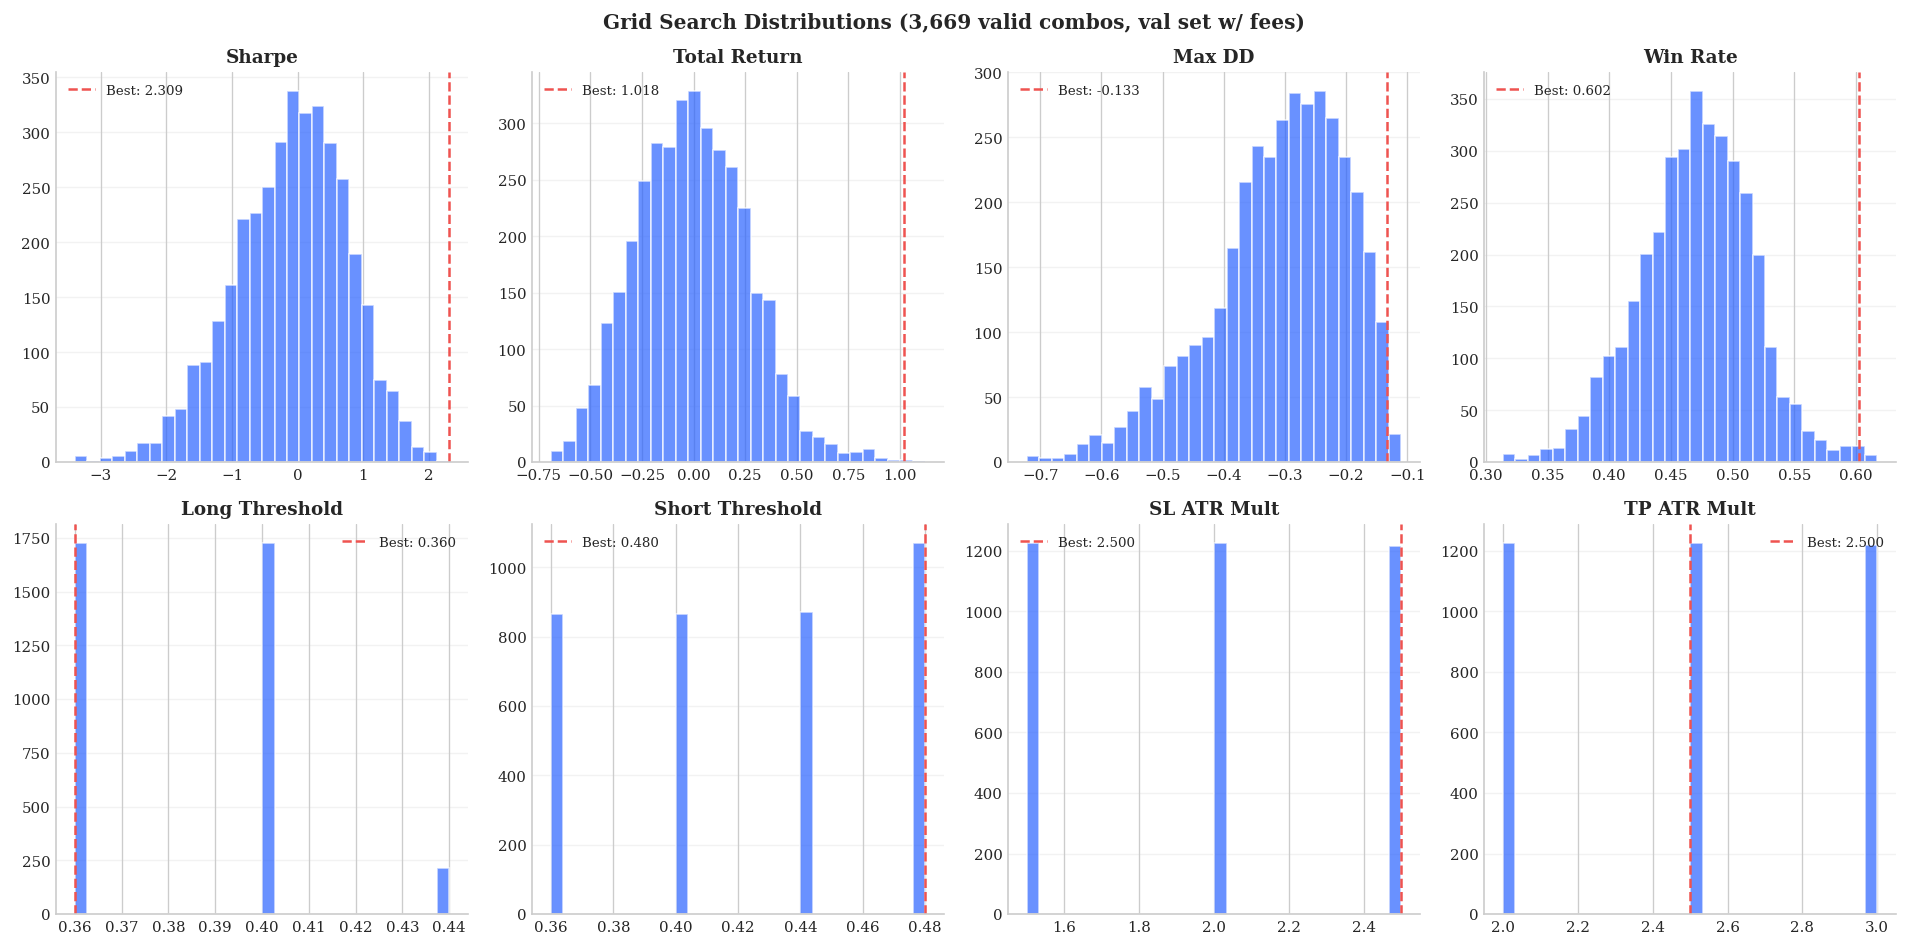

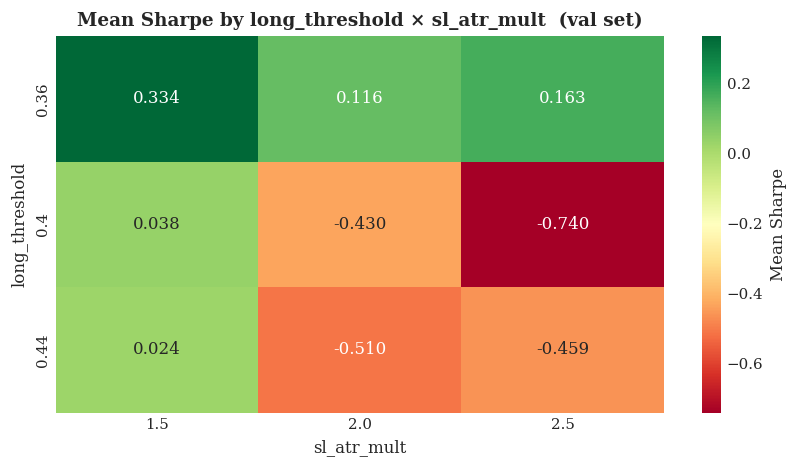

In [19]:
# Grid search: distribution plots
if len(grid_df) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    for ax, col, lbl in zip(axes, 
        ['sharpe','total_ret','maxdd','win_rate',
         'long_threshold','short_threshold','sl_atr_mult','tp_atr_mult'],
        ['Sharpe','Total Return','Max DD','Win Rate',
         'Long Threshold','Short Threshold','SL ATR Mult','TP ATR Mult']):
        data = grid_df[col].dropna()
        ax.hist(data, bins=30, color=BLUE, alpha=0.7, edgecolor='white')
        best_v = grid_df.iloc[0][col]
        ax.axvline(best_v, color=RED, lw=1.5, ls='--', label=f'Best: {best_v:.3f}')
        ax.set_title(lbl, fontweight='bold'); ax.legend(fontsize=8); ax.grid(axis='y',alpha=0.25)

    fig.suptitle(f'Grid Search Distributions ({len(grid_df):,} valid combos, val set w/ fees)',
                 fontweight='bold')
    fig.tight_layout()
    fig.savefig(ARTS_DIR / '05_grid_distributions.png')
    plt.show()

    # Heatmap: long_threshold × sl_atr_mult
    piv = grid_df.pivot_table(index='long_threshold', columns='sl_atr_mult',
                               values='sharpe', aggfunc='mean')
    fig2, ax2 = plt.subplots(figsize=(7, 4))
    sns.heatmap(piv, ax=ax2, cmap='RdYlGn', annot=True, fmt='.3f',
                cbar_kws={'label':'Mean Sharpe'})
    ax2.set_title('Mean Sharpe by long_threshold × sl_atr_mult  (val set)', fontweight='bold')
    fig2.tight_layout()
    fig2.savefig(ARTS_DIR / '06_grid_heatmap.png')
    plt.show()

## 12. Test backtest (held-out: 2024-11-10 → latest)

Best grid-search params applied to the held-out test set.
This period is **identical to the LGBM v12 ATH window**, enabling a direct comparison.

> **No selection leakage**: the grid was searched on the val set (2024-01-01 → 2024-11-10).
> The test set was never seen during training or parameter selection.

In [20]:
_n_te = len(probs_test)
_te_start = SEQ_LEN
_te_pu    = probs_test[:, 1]
_te_pd    = probs_test[:, 0]
_te_close  = test_df['close'].values[_te_start: _te_start + _n_te]
_te_high   = test_df['high'].values[_te_start:  _te_start + _n_te]
_te_low    = test_df['low'].values[_te_start:   _te_start + _n_te]
_te_atr    = test_df['atr_14_pct'].values[_te_start: _te_start + _n_te]
_te_sma200 = test_df['sma_200'].values[_te_start: _te_start + _n_te]
_te_index  = test_df.index[_te_start: _te_start + _n_te]

eq_fees, trades_fees_raw = _run_backtest(
    _te_pu, _te_pd, _te_close, _te_high, _te_low, _te_atr, _te_sma200,
    with_fees=True,  **BEST)
eq_0fee, trades_0fee_raw = _run_backtest(
    _te_pu, _te_pd, _te_close, _te_high, _te_low, _te_atr, _te_sma200,
    with_fees=False, **BEST)

tdf_fees = pd.DataFrame(trades_fees_raw) if trades_fees_raw else pd.DataFrame(
    columns=['direction','reason','gross','net','hold'])
tdf_0fee = pd.DataFrame(trades_0fee_raw) if trades_0fee_raw else pd.DataFrame(
    columns=['direction','reason','gross','net','hold'])

bh_equity = _te_close / _te_close[0]

print(f'{"":22}  {"Trades":>7}  {"L/S":>9}  {"WinRate":>8}  {"Return":>8}  {"Sharpe":>7}  {"MaxDD":>7}')
print('─'*72)
for lbl, eq, tdf in [
    ('With fees (primary)',    eq_fees, tdf_fees),
    ('Zero-fee (upper bound)', eq_0fee, tdf_0fee),
]:
    if len(tdf): wr = float((tdf['net']>0).mean()); n_l=int((tdf['direction']=='long').sum()); n_s=int((tdf['direction']=='short').sum())
    else:        wr=0.; n_l=n_s=0
    print(f'{lbl:22}  {len(tdf):>7}  {n_l:>4}/{n_s:<4}  {wr:>8.1%}  '
          f'{eq[-1]-1:>+7.1%}  {_sharpe(eq):>7.3f}  {_maxdd(eq):>7.2%}')

print(f'\nBTC Buy & Hold  :  {bh_equity[-1]-1:>+7.1%}  Sharpe={_sharpe(bh_equity):.3f}  MaxDD={_maxdd(bh_equity):.2%}')
print(f'Alpha vs B&H    :  {eq_fees[-1]-bh_equity[-1]:>+7.2%}')

if len(tdf_fees):
    print(f'\nFee drag (avg/trade): {(tdf_fees["gross"]-tdf_fees["net"]).mean()*100:.4f}%')
    by_dir = tdf_fees.groupby('direction').agg(
        trades=('net','count'), wr=('net',lambda x:(x>0).mean()),
        avg_net=('net','mean'), avg_gross=('gross','mean')
    ).round(4)
    print('\nBy direction:'); print(by_dir.to_string())
    by_reason = tdf_fees.groupby('reason').agg(
        count=('net','count'), wr=('net',lambda x:(x>0).mean()), avg_net=('net','mean')
    ).round(4)
    print('\nBy exit reason:'); print(by_reason.to_string())


                         Trades        L/S   WinRate    Return   Sharpe    MaxDD
────────────────────────────────────────────────────────────────────────
With fees (primary)         298   205/93       49.3%   -12.0%   -0.246  -36.63%
Zero-fee (upper bound)      298   205/93       50.0%    -2.6%   -0.050  -35.48%

BTC Buy & Hold  :    -8.4%  Sharpe=-0.126  MaxDD=-50.08%
Alpha vs B&H    :   -3.58%

Fee drag (avg/trade): 0.0270%

By direction:
           trades     wr  avg_net  avg_gross
direction                                   
long          205 0.4927  -0.0006    -0.0002
short          93 0.4946   0.0007     0.0008

By exit reason:
         count     wr  avg_net
reason                        
sl          95 0.0000  -0.0272
timeout    100 0.4400  -0.0018
tp         103 1.0000   0.0264


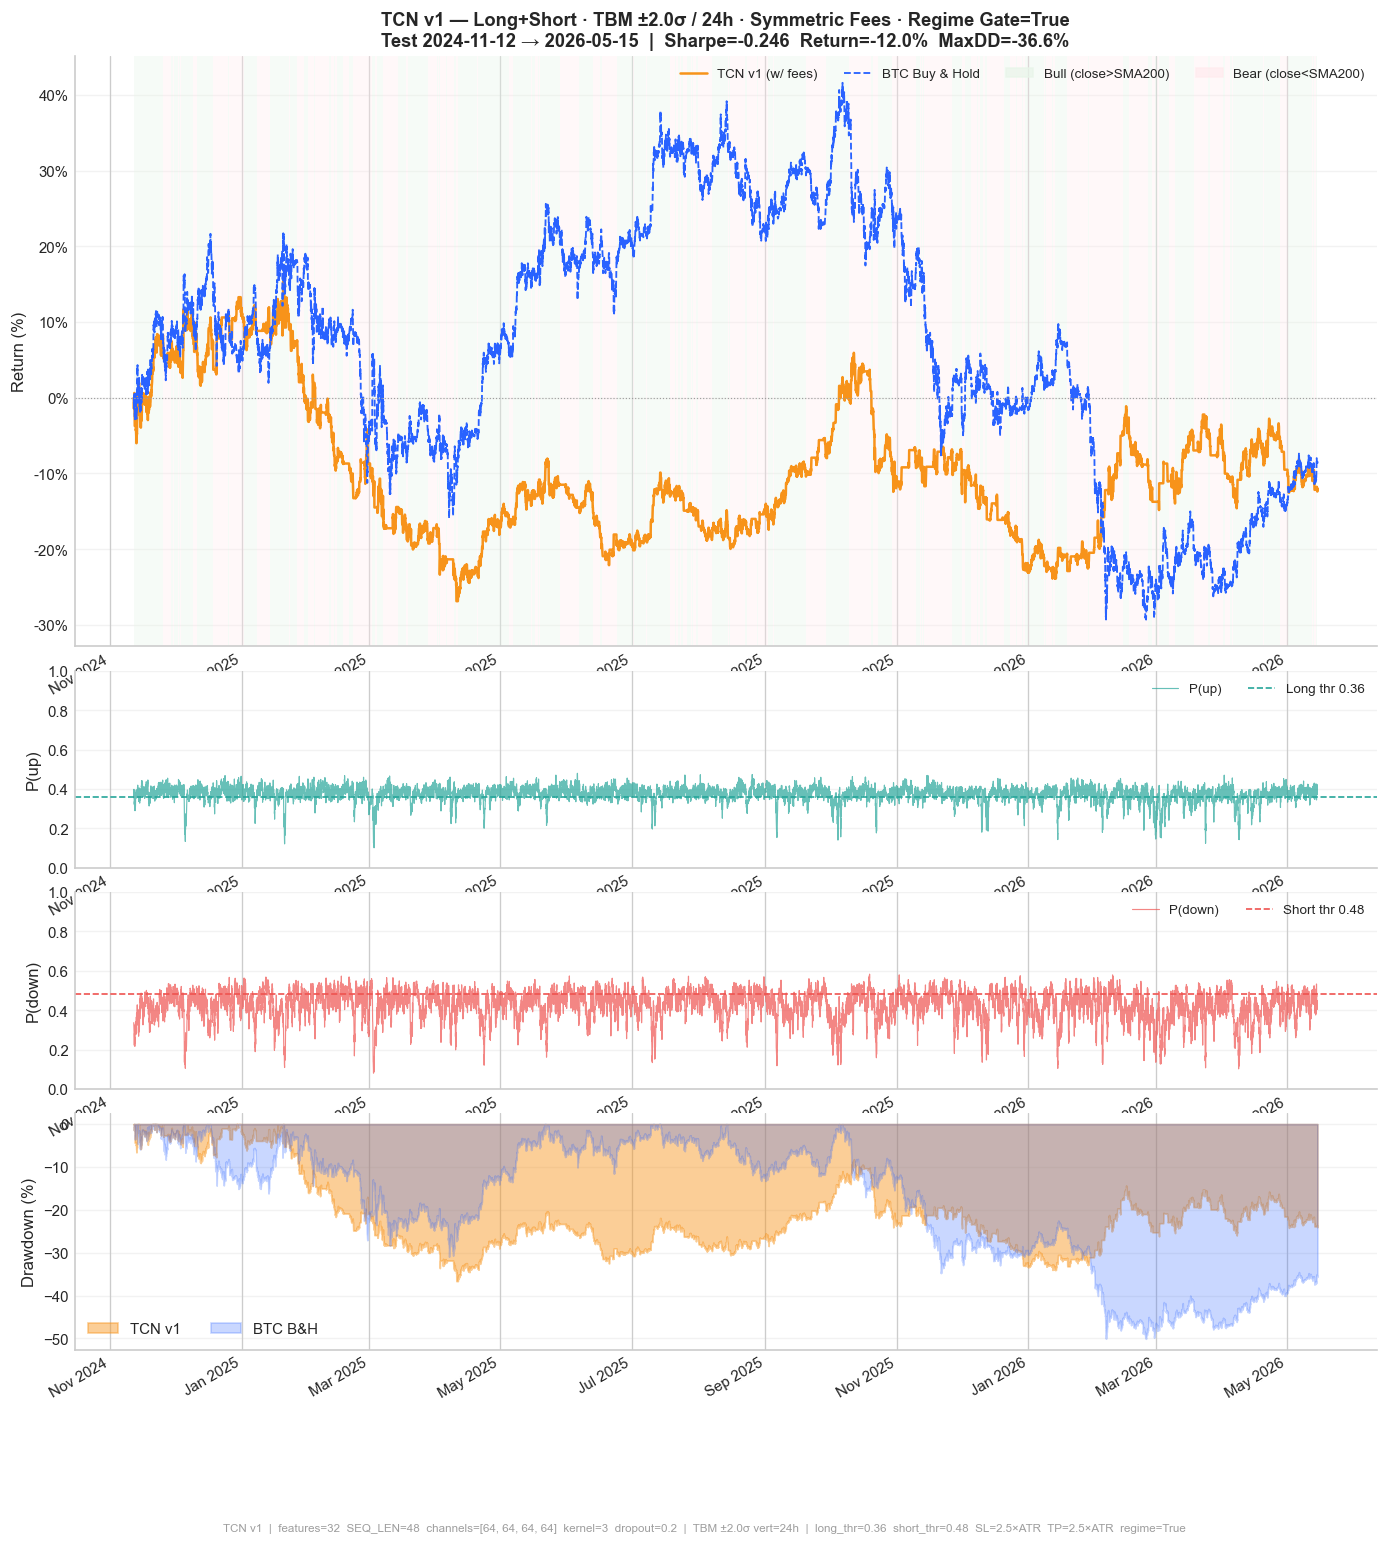

In [21]:
from hmats.viz.plots import save_fig as _save_fig

# Build bull/bear regime mask for shading
_bull_mask = _te_close > _te_sma200

fig, axes = plt.subplots(4, 1, figsize=(14, 14),
                         gridspec_kw={'height_ratios':[3,1,1,1.2], 'hspace':0.08})

# ── Equity ────────────────────────────────────────────────────────────────────
ax = axes[0]

# Shade bull/bear regimes
_regime_changes = np.where(np.diff(_bull_mask.astype(int)))[0]
_seg_starts = np.concatenate([[0], _regime_changes+1])
_seg_ends   = np.concatenate([_regime_changes+1, [len(_te_index)]])
for s, e in zip(_seg_starts, _seg_ends):
    if s < len(_te_index) and e <= len(_te_index):
        color = '#E8F5E9' if _bull_mask[s] else '#FFEBEE'  # light green/red
        ax.axvspan(_te_index[s], _te_index[min(e,len(_te_index)-1)],
                   alpha=0.35, color=color, lw=0)

ax.plot(_te_index, (eq_fees-1)*100, color=ACCENT, lw=1.5, label='TCN v1 (w/ fees)')
ax.plot(_te_index, (bh_equity-1)*100, color=BLUE, lw=1.1, ls='--', label='BTC Buy & Hold')
ax.axhline(0, color=GREY, lw=0.7, ls=':')

# Regime legend patches
import matplotlib.patches as mpatches
bull_patch = mpatches.Patch(color='#E8F5E9', alpha=0.7, label='Bull (close>SMA200)')
bear_patch = mpatches.Patch(color='#FFEBEE', alpha=0.7, label='Bear (close<SMA200)')

sh=_sharpe(eq_fees); ret=eq_fees[-1]-1; dd=_maxdd(eq_fees)
ax.set_title(
    f'TCN v1 — Long+Short · TBM ±{TBM_MULT}σ / {TBM_VERT_H}h · Symmetric Fees · Regime Gate={BEST["regime_filter"]}\n'
    f'Test {_te_index[0].date()} → {_te_index[-1].date()}  |  '
    f'Sharpe={sh:.3f}  Return={ret:+.1%}  MaxDD={dd:.1%}',
    fontweight='bold'
)
ax.set_ylabel('Return (%)')
ax.legend(handles=[ax.lines[0], ax.lines[1], bull_patch, bear_patch], ncol=4, fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}%'))
ax.grid(axis='y', alpha=0.25)

# ── P(up) ─────────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(_te_index, _te_pu, color=GREEN, lw=0.7, alpha=0.7, label='P(up)')
ax.axhline(BEST['long_threshold'], color=GREEN, ls='--', lw=1,
           label=f'Long thr {BEST["long_threshold"]}')
ax.set_ylim(0, 1); ax.set_ylabel('P(up)'); ax.legend(ncol=2, fontsize=8)
ax.grid(axis='y', alpha=0.25)

# ── P(down) ───────────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(_te_index, _te_pd, color=RED, lw=0.7, alpha=0.7, label='P(down)')
ax.axhline(BEST['short_threshold'], color=RED, ls='--', lw=1,
           label=f'Short thr {BEST["short_threshold"]}')
ax.set_ylim(0, 1); ax.set_ylabel('P(down)'); ax.legend(ncol=2, fontsize=8)
ax.grid(axis='y', alpha=0.25)

# ── Drawdown ──────────────────────────────────────────────────────────────────
ax = axes[3]
pk_s = np.maximum.accumulate(eq_fees); pk_b = np.maximum.accumulate(bh_equity)
ax.fill_between(_te_index, (eq_fees-pk_s)/(pk_s+1e-12)*100, 0,
                color=ACCENT, alpha=0.45, label='TCN v1')
ax.fill_between(_te_index, (bh_equity-pk_b)/(pk_b+1e-12)*100, 0,
                color=BLUE, alpha=0.25, label='BTC B&H')
ax.set_ylabel('Drawdown (%)'); ax.legend(ncol=2)
ax.grid(axis='y', alpha=0.25)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,3,5,7,9,11]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.text(0.5, 0.002,
    f'TCN v1  |  features={len(ALL_FEATURES)}  SEQ_LEN={SEQ_LEN}  '
    f'channels={TCN_CHANNELS}  kernel={TCN_KERNEL}  dropout={TCN_DROPOUT}  '
    f'|  TBM ±{TBM_MULT}σ vert={TBM_VERT_H}h  '
    f'|  long_thr={BEST["long_threshold"]}  short_thr={BEST["short_threshold"]}  '
    f'SL={BEST["sl_atr_mult"]}×ATR  TP={BEST["tp_atr_mult"]}×ATR  '
    f'regime={BEST["regime_filter"]}',
    ha='center', fontsize=7, color=GREY)

fig.savefig(ARTS_DIR / '07_equity_curve_v1.png')
plt.show()


Directional Breakdown (test set, w/ fees):
  Direction   Trades   WinRate    AvgPnL   MedianPnL   TotalRet
  ───────────────────────────────────────────────────────
  Long           205     49.3%    -0.057%      -0.074%     -15.53%
  Short           93     49.5%    +0.071%      -0.010%      +3.99%


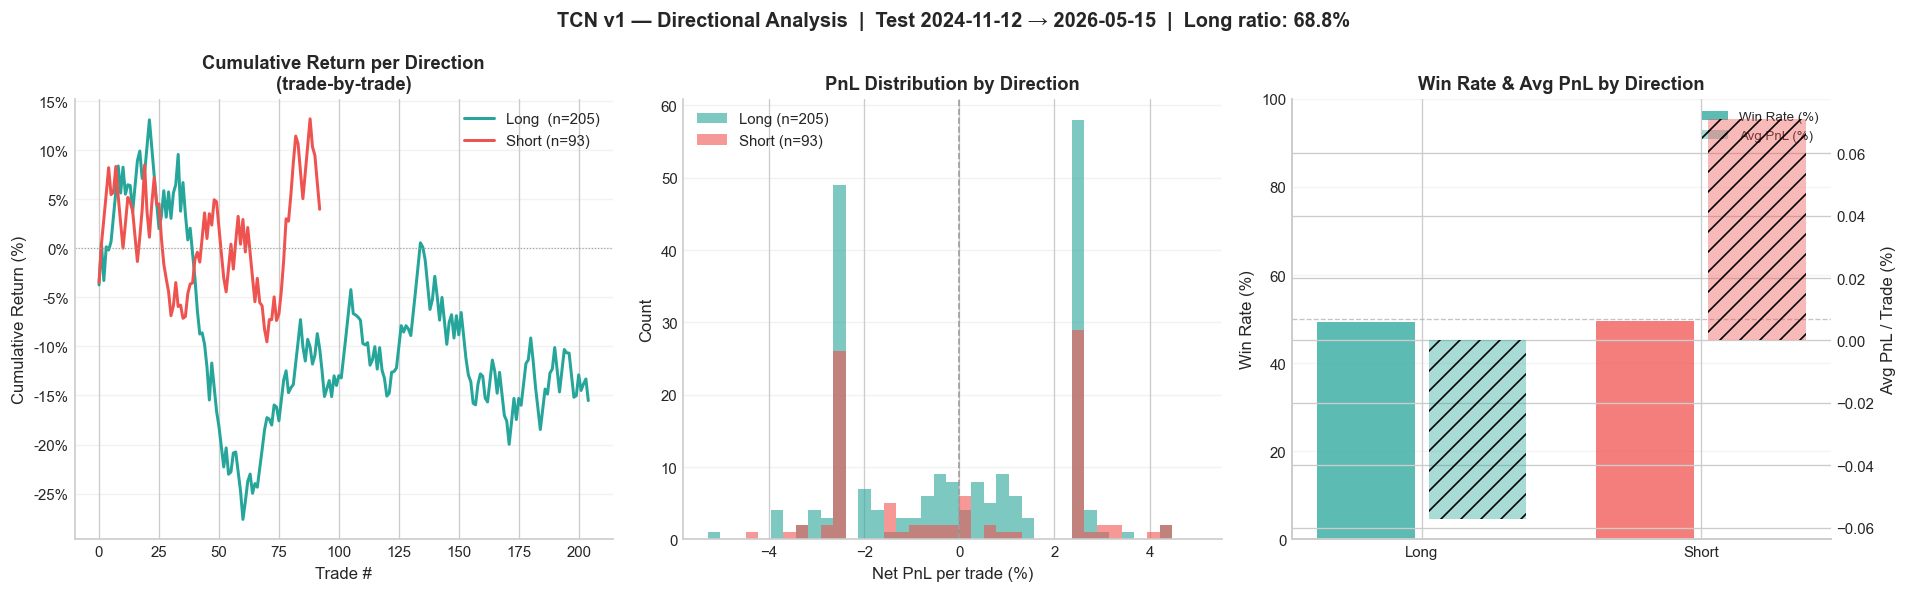

In [22]:
# ── Directional breakdown: separate long & short equity curves ───────────────
if len(tdf_fees) >= 5:
    # Rebuild equity for long-only and short-only subsets
    eq_long_only  = np.ones(len(_te_close))
    eq_short_only = np.ones(len(_te_close))
    cur_l = cur_s = 1.0

    # We need to replay trades on the equity curve timeline.
    # Approximate: assign each trade to its position in the timeline.
    # For a clean split we just compute cumulative PnL per direction.
    long_trades  = tdf_fees[tdf_fees['direction']=='long'].reset_index(drop=True)
    short_trades = tdf_fees[tdf_fees['direction']=='short'].reset_index(drop=True)

    def _cumret(trades_sub):
        if len(trades_sub) == 0: return np.array([0.0])
        return np.cumprod(1 + trades_sub['net'].values) - 1

    cr_l = _cumret(long_trades)
    cr_s = _cumret(short_trades)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Left: cumulative return per direction (trade-by-trade)
    ax = axes[0]
    ax.plot(cr_l * 100, color=GREEN,  lw=1.8, label=f'Long  (n={len(long_trades)})')
    ax.plot(cr_s * 100, color=RED,    lw=1.8, label=f'Short (n={len(short_trades)})')
    ax.axhline(0, color=GREY, lw=0.7, ls=':')
    ax.set_xlabel('Trade #'); ax.set_ylabel('Cumulative Return (%)')
    ax.set_title('Cumulative Return per Direction\n(trade-by-trade)', fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.25)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}%'))

    # Middle: PnL distribution by direction
    ax = axes[1]
    bins = np.linspace(
        min(tdf_fees['net'].min(), -0.05),
        max(tdf_fees['net'].max(),  0.05),
        40
    ) * 100
    if len(long_trades):
        ax.hist(long_trades['net']*100, bins=bins, color=GREEN, alpha=0.6, label=f'Long (n={len(long_trades)})')
    if len(short_trades):
        ax.hist(short_trades['net']*100, bins=bins, color=RED,   alpha=0.6, label=f'Short (n={len(short_trades)})')
    ax.axvline(0, color=GREY, lw=1, ls='--')
    ax.set_xlabel('Net PnL per trade (%)'); ax.set_ylabel('Count')
    ax.set_title('PnL Distribution by Direction', fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.25)

    # Right: win rate & avg PnL comparison bar chart
    ax = axes[2]
    dirs = ['Long', 'Short']
    wrs  = [
        float((long_trades['net']>0).mean())  if len(long_trades)  else 0.,
        float((short_trades['net']>0).mean()) if len(short_trades) else 0.,
    ]
    avgs = [
        float(long_trades['net'].mean()*100)  if len(long_trades)  else 0.,
        float(short_trades['net'].mean()*100) if len(short_trades) else 0.,
    ]
    x = np.arange(2)
    bars = ax.bar(x - 0.2, [w*100 for w in wrs], 0.35,
                  color=[GREEN, RED], alpha=0.75, label='Win Rate (%)')
    ax2b = ax.twinx()
    ax2b.bar(x + 0.2, avgs, 0.35, color=[GREEN, RED], alpha=0.40, hatch='//',
             label='Avg PnL (%)')
    ax.set_xticks(x); ax.set_xticklabels(dirs)
    ax.set_ylabel('Win Rate (%)'); ax2b.set_ylabel('Avg PnL / Trade (%)')
    ax.set_title('Win Rate & Avg PnL by Direction', fontweight='bold')
    ax.axhline(50, color=GREY, lw=0.8, ls='--', alpha=0.6)
    ax.set_ylim(0, 100); ax.grid(axis='y', alpha=0.2)
    # Combined legend
    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2b.get_legend_handles_labels()
    ax.legend(handles1+handles2, labels1+labels2, fontsize=8)

    # Print stats
    print('Directional Breakdown (test set, w/ fees):')
    print(f'  {"Direction":<10} {"Trades":>7}  {"WinRate":>8}  {"AvgPnL":>8}  {"MedianPnL":>10}  {"TotalRet":>9}')
    print('  ' + '─'*55)
    for lbl, tr in [('Long', long_trades), ('Short', short_trades)]:
        if len(tr) == 0:
            print(f'  {lbl:<10} {"0":>7}  {"—":>8}  {"—":>8}  {"—":>10}  {"—":>9}')
        else:
            tot = (1 + tr['net']).prod() - 1
            print(f'  {lbl:<10} {len(tr):>7}  {(tr["net"]>0).mean():>8.1%}  '
                  f'{tr["net"].mean()*100:>+8.3f}%  {tr["net"].median()*100:>+10.3f}%  '
                  f'{tot*100:>+9.2f}%')

    fig.suptitle(
        f'TCN v1 — Directional Analysis  |  Test {_te_index[0].date()} → {_te_index[-1].date()}  '
        f'|  Long ratio: {len(long_trades)/len(tdf_fees):.1%}',
        fontweight='bold'
    )
    fig.tight_layout()
    fig.savefig(ARTS_DIR / '11_directional_breakdown.png')
    plt.show()
else:
    print('Not enough trades for directional breakdown.')


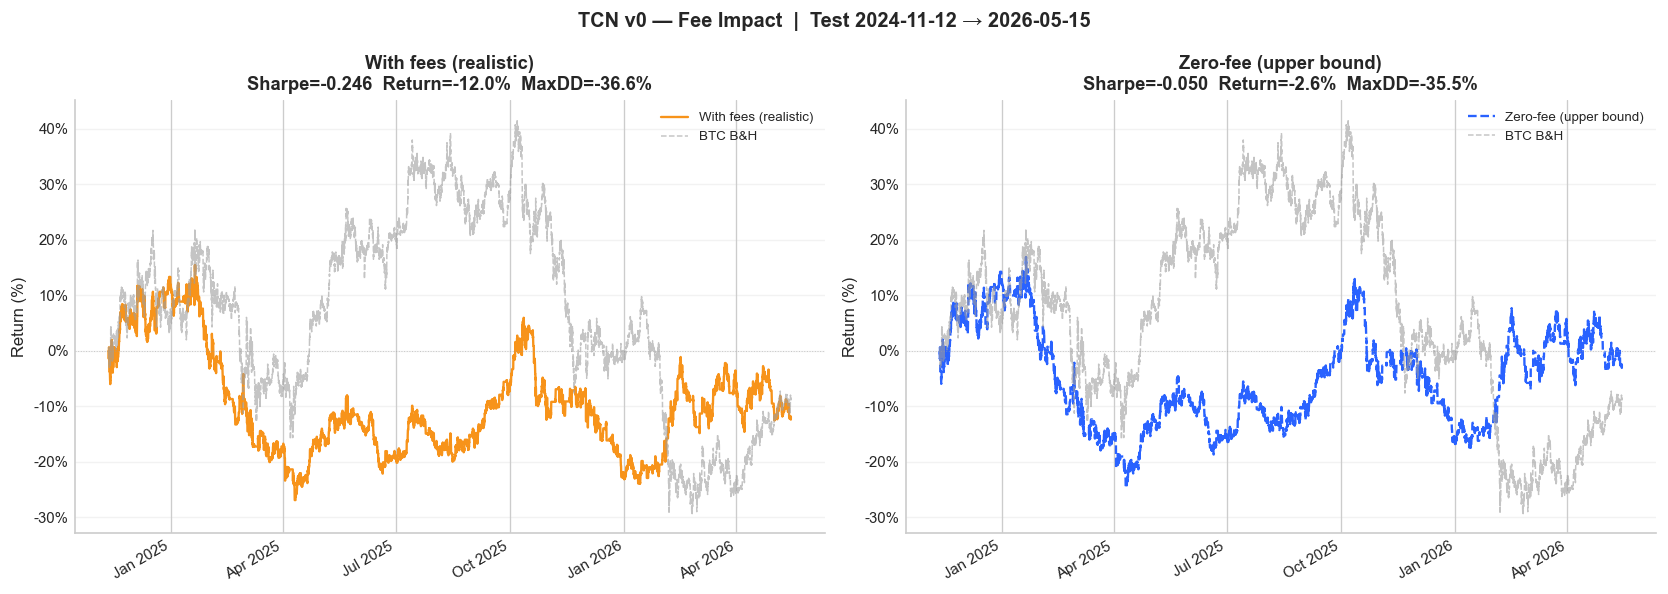

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (lbl, eq, col, ls) in zip(axes, [
    ('With fees (realistic)',  eq_fees, ACCENT, '-'),
    ('Zero-fee (upper bound)', eq_0fee, BLUE,   '--'),
]):
    ax.plot(_te_index, (eq-1)*100,         color=col,  lw=1.4, ls=ls,  label=lbl)
    ax.plot(_te_index, (bh_equity-1)*100,  color=GREY, lw=0.9, ls='--',alpha=0.6, label='BTC B&H')
    ax.axhline(0, color=GREY, lw=0.6, ls=':', alpha=0.5)
    sh=_sharpe(eq); rt=eq[-1]-1; md=_maxdd(eq)
    ax.set_title(f'{lbl}\nSharpe={sh:.3f}  Return={rt:+.1%}  MaxDD={md:.1%}', fontweight='bold')
    ax.set_ylabel('Return (%)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}%'))
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.25)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle(f'TCN v0 — Fee Impact  |  Test {_te_index[0].date()} → {_te_index[-1].date()}',
             fontweight='bold')
fig.tight_layout()
fig.savefig(ARTS_DIR / '08_fee_comparison.png')
plt.show()

## 13. Monthly return analysis

Monthly stats (w/ fees, test set):
  Positive months : 10 / 19
  Avg monthly ret : -0.67%
  Median monthly  : +0.07%
  Best month      : +9.77%  (Sep 2025)
  Worst month     : -17.07%  (Dec 2025)
  Monthly std dev : 7.42%

open_time
2024-11-30     0.0000
2024-12-31     5.2887
2025-01-31   -12.5924
2025-02-28    -5.9001
2025-03-31    -9.2486
2025-04-30     0.0695
2025-05-31     5.6937
2025-06-30    -7.7337
2025-07-31     2.7257
2025-08-31     2.8443
2025-09-30     9.7701
2025-10-31    -4.9790
2025-11-30     4.2504
2025-12-31   -17.0694
2026-01-31     5.9086
2026-02-28     5.8204
2026-03-31     8.3091
2026-04-30    -3.1324
2026-05-31    -2.7295
Freq: ME


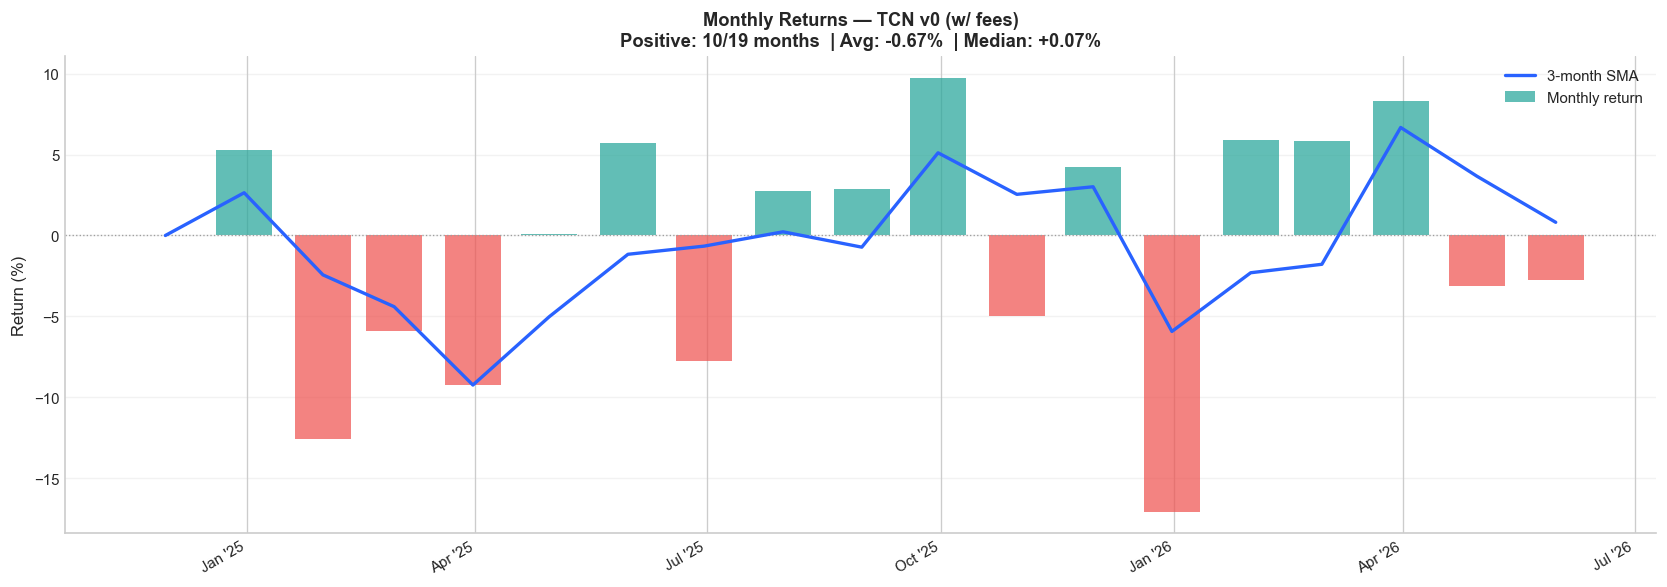

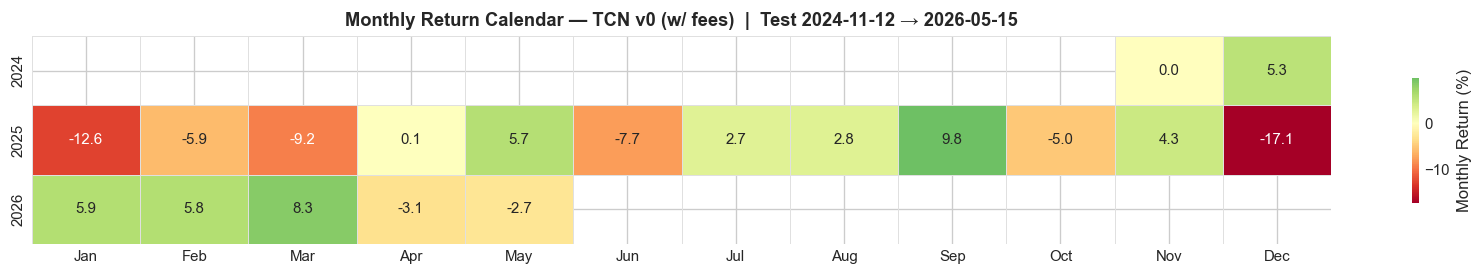

In [24]:
eq_series  = pd.Series(eq_fees, index=_te_index)
monthly_eq = eq_series.resample('ME').last()
monthly_ret= monthly_eq.pct_change().fillna(0) * 100
sma3       = monthly_ret.rolling(3, min_periods=1).mean()

print('Monthly stats (w/ fees, test set):')
print(f'  Positive months : {(monthly_ret>0).sum()} / {len(monthly_ret)}')
print(f'  Avg monthly ret : {monthly_ret.mean():+.2f}%')
print(f'  Median monthly  : {monthly_ret.median():+.2f}%')
print(f'  Best month      : {monthly_ret.max():+.2f}%  ({monthly_ret.idxmax().strftime("%b %Y")})')
print(f'  Worst month     : {monthly_ret.min():+.2f}%  ({monthly_ret.idxmin().strftime("%b %Y")})')
print(f'  Monthly std dev : {monthly_ret.std():.2f}%')
print()
print(monthly_ret.to_string())

fig, ax = plt.subplots(figsize=(14, 5))
colors = [GREEN if r >= 0 else RED for r in monthly_ret.values]
ax.bar(monthly_ret.index, monthly_ret.values, color=colors, alpha=0.72, width=22, label='Monthly return')
ax.plot(monthly_ret.index, sma3.values, color=BLUE, lw=2.0, label='3-month SMA', zorder=5)
ax.axhline(0, color=GREY, lw=0.8, ls=':')
ax.set_ylabel('Return (%)')
ax.set_title(f'Monthly Returns — TCN v0 (w/ fees)\n'
             f'Positive: {(monthly_ret>0).sum()}/{len(monthly_ret)} months  '
             f'| Avg: {monthly_ret.mean():+.2f}%  | Median: {monthly_ret.median():+.2f}%',
             fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.25)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
fig.tight_layout()
fig.savefig(ARTS_DIR / '09_monthly_returns.png')
plt.show()

# Calendar heatmap
cal_df = monthly_ret.to_frame('ret')
cal_df['year'] = cal_df.index.year; cal_df['month'] = cal_df.index.month
pivot = cal_df.pivot(index='year', columns='month', values='ret')
pivot.columns = [calendar.month_abbr[m] for m in pivot.columns]
fig2, ax2 = plt.subplots(figsize=(14, max(2, len(pivot)*0.8)))
sns.heatmap(pivot, ax=ax2, cmap='RdYlGn', center=0, annot=True, fmt='.1f',
            linewidths=0.5, linecolor='#e0e0e0', annot_kws={'size': 9},
            cbar_kws={'label':'Monthly Return (%)','shrink':0.6})
ax2.set_title(f'Monthly Return Calendar — TCN v0 (w/ fees)  |  '
              f'Test {_te_index[0].date()} → {_te_index[-1].date()}',
              fontweight='bold')
ax2.set_xlabel(''); ax2.set_ylabel('')
fig2.tight_layout()
fig2.savefig(ARTS_DIR / '10_monthly_heatmap.png')
plt.show()

## 14. Strategy summary

Key metrics compared to **LGBM v12** (same ATH test window).

In [25]:
if len(tdf_fees):
    pnl = tdf_fees['net']
    pnl_pct = pnl * 100
    long_t  = tdf_fees[tdf_fees['direction']=='long']
    short_t = tdf_fees[tdf_fees['direction']=='short']

    print('=' * 68)
    print('  STRATEGY SUMMARY — TCN v1 (Regime Gate · Symmetric Fees · Balance)')
    print('=' * 68)
    print(f'  Features        : {len(ALL_FEATURES)}  SEQ_LEN={SEQ_LEN}')
    print(f'  TBM barriers    : ±{TBM_MULT}σ (24h rolling)  vertical={TBM_VERT_H}h')
    print(f'  Test period     : {_te_index[0].date()} → {_te_index[-1].date()}')
    print(f'  Regime filter   : {BEST["regime_filter"]}')
    print(f'  Total trades    : {len(tdf_fees)}  (Long: {len(long_t)}, Short: {len(short_t)})'
          f'  long_ratio={len(long_t)/len(tdf_fees):.1%}')
    print(f'  Win rate        : {(pnl>0).mean()*100:.1f}%  '
          f'({(pnl>0).sum()} wins / {(pnl<=0).sum()} losses)')
    print()
    print('  Exit reasons:')
    for reason, grp in tdf_fees.groupby('reason'):
        wr = (grp['net']>0).mean()*100
        print(f'    {reason:<12}  n={len(grp):>3}  win={wr:.1f}%  '
              f'avg_pnl={grp["net"].mean()*100:+.2f}%')
    print()
    print('  Return percentiles (% per trade):')
    for p in [5, 25, 50, 75, 95]:
        print(f'    p{p:<4}  {pnl_pct.quantile(p/100):>+7.2f}%')
    print(f'    mean  {pnl_pct.mean():>+7.2f}%   std {pnl_pct.std():>6.2f}%')
    print()
    print(f'  Hold duration   : mean={tdf_fees["hold"].mean():.1f}h  '
          f'median={tdf_fees["hold"].median():.1f}h')
    print()
    print(f'  Final equity    : {eq_fees[-1]:.4f}')
    print(f'  Total return    : {(eq_fees[-1]-1)*100:+.2f}%')
    print(f'  Zero-fee return : {(eq_0fee[-1]-1)*100:+.2f}%')
    print(f'  BTC B&H return  : {(bh_equity[-1]-1)*100:+.2f}%')
    print(f'  Alpha vs B&H    : {(eq_fees[-1]-bh_equity[-1])*100:+.2f}pp')
    print(f'  Sharpe (ann.)   : {_sharpe(eq_fees):.3f}')
    print(f'  Max drawdown    : {_maxdd(eq_fees)*100:.2f}%')
    print()
    print('  ── Comparison table ──────────────────────────────────────────────')
    print(f'  {"Model":<15}  {"Sharpe":>7}  {"Return":>8}  {"MaxDD":>8}  {"Trades":>7}  {"L/S":>9}')
    print('  ' + '─'*60)
    print(f'  {"LGBM v12":<15}  {0.675:>+7.3f}  {0.329:>+8.1%}  {-0.1924:>8.2%}  '
          f'{416:>7}  {"?/?":>9}')
    print(f'  {"TCN v0":<15}  {0.457:>+7.3f}  {"N/A":>8}  {"N/A":>8}  '
          f'{595:>7}  {"53/542":>9}')
    print(f'  {"TCN v1":<15}  {_sharpe(eq_fees):>+7.3f}  {eq_fees[-1]-1:>+8.1%}  '
          f'{_maxdd(eq_fees):>8.2%}  {len(tdf_fees):>7}  '
          f'{len(long_t):>4}/{len(short_t):<4}')
    print('=' * 68)
else:
    print('No trades generated. Adjust thresholds.')
    print(f'P(up)   fraction ≥ {BEST["long_threshold"]}: {(_te_pu>=BEST["long_threshold"]).mean()*100:.1f}%')
    print(f'P(down) fraction ≥ {BEST["short_threshold"]}: {(_te_pd>=BEST["short_threshold"]).mean()*100:.1f}%')


  STRATEGY SUMMARY — TCN v1 (Regime Gate · Symmetric Fees · Balance)
  Features        : 32  SEQ_LEN=48
  TBM barriers    : ±2.0σ (24h rolling)  vertical=24h
  Test period     : 2024-11-12 → 2026-05-15
  Regime filter   : True
  Total trades    : 298  (Long: 205, Short: 93)  long_ratio=68.8%
  Win rate        : 49.3%  (147 wins / 151 losses)

  Exit reasons:
    sl            n= 95  win=0.0%  avg_pnl=-2.72%
    timeout       n=100  win=44.0%  avg_pnl=-0.18%
    tp            n=103  win=100.0%  avg_pnl=+2.64%

  Return percentiles (% per trade):
    p5       -2.89%
    p25      -2.54%
    p50      -0.05%
    p75      +2.50%
    p95      +2.79%
    mean    -0.02%   std   2.29%

  Hold duration   : mean=29.2h  median=29.0h

  Final equity    : 0.8803
  Total return    : -11.97%
  Zero-fee return : -2.57%
  BTC B&H return  : -8.38%
  Alpha vs B&H    : -3.58pp
  Sharpe (ann.)   : -0.246
  Max drawdown    : -36.63%

  ── Comparison table ──────────────────────────────────────────────
  Model

In [26]:
def _bt_metrics(eq, tdf):
    wr  = float((tdf['net']>0).mean()) if len(tdf) else 0.
    n_l = int((tdf['direction']=='long').sum())  if len(tdf) else 0
    n_s = int((tdf['direction']=='short').sum()) if len(tdf) else 0
    return {'n_trades':len(tdf),'n_long':n_l,'n_short':n_s,'win_rate':round(wr,4),
            'long_ratio':round(n_l/max(len(tdf),1),4),
            'total_ret':round(float(eq[-1]-1),4),'sharpe':round(_sharpe(eq),4),
            'maxdd':round(_maxdd(eq),4)}

results = {
    'notebook': '06_tcn_omni_0fee_v1',
    'created': pd.Timestamp.now().isoformat(),
    'symbol': SYMBOL, 'interval': INTERVAL,
    'train_period': f'start → {TRAIN_END}',
    'val_period':   f'{TRAIN_END} → {VAL_END}',
    'test_period':  f'{VAL_END} → {_te_index[-1].date()}',
    'architecture': {
        'model': 'TCNMultiTask', 'channels': TCN_CHANNELS,
        'kernel': TCN_KERNEL, 'dropout': TCN_DROPOUT,
        'seq_len': SEQ_LEN, 'n_features': len(ALL_FEATURES),
        'n_params': n_params, 'receptive_field': rf,
    },
    'labels': {'type':'TBM','mult':TBM_MULT,'vol_window':TBM_VOL_WINDOW,'vert_h':TBM_VERT_H},
    'training': {'epochs':EPOCHS,'lr':LR,'weight_decay':WEIGHT_DECAY,'batch_size':BATCH_SIZE,
                 'lambda_vol':LAMBDA_VOL,'best_epoch':best_epoch,'best_val_loss':round(best_vl,5)},
    'classification': test_metrics,
    'fees': {
        'maker':MAKER_FEE,'spot_taker':SPOT_TAKER_FEE,'futures_taker':FUTURES_TAKER_FEE,
        'buffer':BUFFER,'short_funding_h':SHORT_FUNDING_H,
        'long_fee_model':'symmetric limit-entry (maker 0% if filled, spot_taker fallback), maker TP',
        'short_fee_model':'symmetric limit-entry (maker 0% if filled, futures_taker fallback), maker TP',
        'v1_change':'symmetric limit-entry for longs (was all-taker in v0)',
    },
    'regime_filter': BEST['regime_filter'],
    'min_long_ratio': MIN_LONG_RATIO,
    'grid': {'total_combos':len(_all_combos),'valid_combos':len(grid_df),'best_params':BEST},
    'backtest_wfees': _bt_metrics(eq_fees, tdf_fees),
    'backtest_0fee':  _bt_metrics(eq_0fee, tdf_0fee),
    'bh_return': round(float(bh_equity[-1]-1),4),
    'alpha_vs_bh': round(float(eq_fees[-1]-bh_equity[-1]),4),
    'monthly': {
        'positive_months': int((monthly_ret>0).sum()),
        'total_months': int(len(monthly_ret)),
        'mean_pct': round(float(monthly_ret.mean()),3),
        'median_pct': round(float(monthly_ret.median()),3),
        'std_pct': round(float(monthly_ret.std()),3),
    },
    'features': ALL_FEATURES,
    'comparison': {
        'lgbm_v12':  {'sharpe':0.675,'total_ret':0.329,'maxdd':-0.1924,'n_trades':416},
        'tcn_v0':    {'sharpe':0.457,'n_long':53,'n_short':542},
        'tcn_v1':    _bt_metrics(eq_fees, tdf_fees),
    },
}

out_path = ARTS_DIR / 'results_v1.json'
with open(out_path, 'w') as f: json.dump(results, f, indent=2)
print(f'Saved → {out_path}')
print(json.dumps({k:v for k,v in results.items() if k not in ['features']}, indent=2)[:2500])


Saved → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/06_tcn_omni_0fee_v0/results_v1.json
{
  "notebook": "06_tcn_omni_0fee_v1",
  "created": "2026-05-31T22:34:30.939675",
  "symbol": "BTCUSDT",
  "interval": "1h",
  "train_period": "start \u2192 2024-01-01",
  "val_period": "2024-01-01 \u2192 2024-11-10",
  "test_period": "2024-11-10 \u2192 2026-05-15",
  "architecture": {
    "model": "TCNMultiTask",
    "channels": [
      64,
      64,
      64,
      64
    ],
    "kernel": 3,
    "dropout": 0.2,
    "seq_len": 48,
    "n_features": 32,
    "n_params": 98788,
    "receptive_field": 61
  },
  "labels": {
    "type": "TBM",
    "mult": 2.0,
    "vol_window": 24,
    "vert_h": 24
  },
  "training": {
    "epochs": 100,
    "lr": 0.0003,
    "weight_decay": 0.0001,
    "batch_size": 256,
    "lambda_vol": 0.5,
    "best_epoch": 5,
    "best_val_loss": 1.12498
  },
  "classification": {
    "acc3": 0.43833953100098655,
    "acc_bin": 0.4682553048164365,
 

## 16. Next steps (v2 improvements)

**If v1 long ratio is still < 15%:**
- Tighten `TBM_MULT = 1.5` (more "up" labels when barriers are closer)
- Add asymmetric TBM: separate `PT_MULT` (take-profit multiplier) and `SL_MULT` (stop-loss)
  with `PT_MULT < SL_MULT` to generate proportionally more long labels
- Try class-reweighting in CE loss: `weight[1] *= 1.5` to boost gradient for up-class

**If regime filter is selected but hurts performance:**
- Check if SMA-200 is stale (computed on raw prices — try EMA-100 instead)
- Use ADX > 20 as regime gate instead of SMA-200 (trend strength vs direction)
- Try a 2-period look-ahead regime: only gate when SMA-200 slope > 0 for longs

**If Sharpe improves vs v0 but < LGBM v12 (0.675):**
- Purged walk-forward refit (720h steps): adapt TCN heads to current regime
- Ensemble TCN P(up) with LGBM P(up) via geometric mean (orthogonal signal sources)
- Extend features to all V4 + structural (up to ~60 features)
- Increase `SEQ_LEN = 72` for 3-day context

**Architecture experiments for v3:**
- `TCN_CHANNELS = [64, 128, 128, 64]` (pyramid bottleneck)
- Attention pooling over temporal dim instead of last-step readout
- Separate encoder for price/volume vs. indicators (dual-branch TCN)
